In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../src")
sys.path.append("../../src")

In [3]:
PDF_PATH = pdf_path = "../../data/XQuality/Textual/Chapitre_8_Alarmes_et_messages.pdf"
MODEL_NAME = model_name = "openai/gpt-oss-20b"

# Ontology modes:
#   None       -> no ontology
#   "minimal"  -> minimal fallback ontology
#   path       -> real ontology file
SEED_ONTOLOGY_INPUT = str("../../data/ontology/ContextOntology-COInd4.owl")
ONTOLOGY_PATH = "../../data/ontology/ContextOntology-COInd4.owl"

### Past

In [ ]:
# ============================================================
# NeoOLAF XQuality Event PDF Runner
# OpenRouter + GPT-OSS-20B
# ============================================================

from __future__ import annotations

import os
import sys
import json
import copy
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# ============================================================
# Path setup
# ============================================================

PROJECT_ROOT = Path("../..").resolve()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# ============================================================
# Minimal .env loader
# ============================================================

def load_dotenv_file(env_path: Path) -> None:
    """Load key=value pairs from a .env file into os.environ."""
    if not env_path.exists():
        print(f"[WARN] .env not found at: {env_path}")
        return

    for line in env_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()

        if not line or line.startswith("#") or "=" not in line:
            continue

        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")

        if key and key not in os.environ:
            os.environ[key] = value


ENV_PATH = PROJECT_ROOT / ".env"
load_dotenv_file(ENV_PATH)

# ============================================================
# NeoOLAF imports
# ============================================================

from neoolaf.core.pipeline import Pipeline
from neoolaf.core.pipeline_state import PipelineState
from neoolaf.core.runner import Runner
from neoolaf.core.execution_config import ExecutionConfig

from neoolaf.domain.documents import Document
from neoolaf.domain.user_guidance import (
    UserGuidance,
    TypingExample,
    RelationExample,
    PromotionExample,
    NegativeExample,
)

from neoolaf.preprocessing.pdf_parsing import extract_text_from_pdf

from neoolaf.resources.llm_backends.openai_backend import OpenAIBackend
from neoolaf.resources.translation.deep_translator_backend import DeepTranslatorBackend

from neoolaf.resources.knowledge_sources.wordnet_source import WordNetSource
from neoolaf.resources.knowledge_sources.wikipedia_source import WikipediaSource
from neoolaf.resources.knowledge_sources.wikidata_source import WikidataSource
from neoolaf.resources.knowledge_sources.web_search_source import WebSearchSource

from neoolaf.ontology.factory import build_seed_ontology

from neoolaf.grounding.rag.registry import RetrievalRegistry
from neoolaf.grounding.rag.engine import SemanticRAGEngine
from neoolaf.grounding.rag.adapters.neoolaf_semantic_rag_adapter import NeoOLAFSemanticRAGAdapter
from neoolaf.grounding.rag.spaces.ontology_space import OntologySpace
from neoolaf.grounding.rag.spaces.artifact_space import ArtifactSpace
from neoolaf.grounding.rag.spaces.web_space import WebSpace
from neoolaf.grounding.rag.spaces.wikidata_space import WikidataSpace
from neoolaf.grounding.rag.spaces.wikipedia_space import WikipediaSpace
from neoolaf.grounding.rag.spaces.wordnet_space import WordNetSpace

from neoolaf.layers.layer00_preprocessing.component import PreprocessingLayer
from neoolaf.layers.layer01_linguistic_expression_extraction.component import LinguisticExpressionExtractionLayer
from neoolaf.layers.layer02_candidate_enrichment.component import CandidateEnrichmentLayer
from neoolaf.layers.layer03_candidate_typing_resolution.component import CandidateTypingResolutionLayer
from neoolaf.layers.layer04_candidate_relation_extraction.component import CandidateRelationExtractionLayer
from neoolaf.layers.layer05_candidate_triple_generation.component import CandidateTripleGenerationLayer
from neoolaf.layers.layer06_concept_relation_induction.component import ConceptRelationInductionLayer
from neoolaf.layers.layer07_hierarchisation.component import HierarchisationLayer
from neoolaf.layers.layer08_axiom_schemata_extraction.component import AxiomSchemataExtractionLayer
from neoolaf.layers.layer09_general_axiom_extraction.component import GeneralAxiomExtractionLayer
from neoolaf.layers.layer10_validation_reasoning.component import ValidationReasoningLayer
from neoolaf.layers.layer11_inference_completion.component import InferenceCompletionLayer
from neoolaf.layers.layer12_serialization.component import SerializationLayer

# ============================================================
# Backend compatibility adapter
# ============================================================

class OpenAIBackendCompatAdapter:
    """
    Adapter around NeoOLAF OpenAIBackend.

    Some NeoOLAF components call:
        backend.chat(model=..., messages=...)

    Other code may call:
        backend.chat(model_name=..., messages=...)

    This adapter accepts both.
    """

    def __init__(self, backend: OpenAIBackend) -> None:
        self.backend = backend

    def chat(
        self,
        model: Optional[str] = None,
        model_name: Optional[str] = None,
        messages: Optional[List[Dict[str, str]]] = None,
        temperature: float = 0.0,
        timeout: Optional[int] = None,
        max_tokens: Optional[int] = None,
        **_: Any,
    ) -> str:
        """Forward the chat request to the OpenAI-compatible backend."""
        selected_model = model or model_name

        if not selected_model:
            raise ValueError("No model/model_name provided to backend.chat().")

        if messages is None:
            raise ValueError("No messages provided to backend.chat().")

        return self.backend.chat(
            model=selected_model,
            messages=messages,
            temperature=temperature,
            timeout=timeout,
            max_tokens=max_tokens,
        )

    @staticmethod
    def extract_json(text: str) -> Any:
        """Expose NeoOLAF OpenAIBackend JSON extraction helper."""
        return OpenAIBackend.extract_json(text)


# ============================================================
# Config
# ============================================================

MODEL_NAME = "openai/gpt-oss-20b"

OPENROUTER_HOST = "https://openrouter.ai/api"
OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY", "")

if not OPENROUTER_KEY:
    raise ValueError(
        "OPENROUTER_API_KEY not found. Add it to your environment or PROJECT_ROOT/.env."
    )

# Ontology paths
SEED_ONTOLOGY_INPUT = str(PROJECT_ROOT / "data/ontology/ContextOntology-COInd4.owl")
ONTOLOGY_PATH = PROJECT_ROOT / "data/ontology/ContextOntology-COInd4.owl"

# Event PDF folder
EVENTS_DIR = PROJECT_ROOT / "data/XQuality/Events"

# Optional JSONs for later comparison
DFT_JSONS = {
    "feedrate_80": EVENTS_DIR / "dft_feed80_exp1.json",
    "material_316L": EVENTS_DIR / "dft_material_exp1.json",
}

# PDF cases
PDF_CASES = [
    {
        "case_id": "feedrate_80",
        "pdf_path": EVENTS_DIR / "Analyse XQuality CETIM Cluses-Février 2026-Feedrate 80 per cent-v4.pdf",
        "fault_tree_json": DFT_JSONS["feedrate_80"],
    },
    {
        "case_id": "material_316L",
        "pdf_path": EVENTS_DIR / "Analyse XQuality CETIM Cluses-Février 2026-316L-v4.pdf",
        "fault_tree_json": DFT_JSONS["material_316L"],
    },
]

# NeoOLAF execution parameters
CHUNK_SIZE = 5000
CHUNK_OVERLAP = 0
MAX_CHUNKS = None
MAX_EXPRESSIONS = None
MAX_RELATION_MENTIONS = None

TRANSLATE_TO_ENGLISH = True
USE_WEB_SEARCH = False

MAX_WORKERS = 8
ENABLE_CHECKPOINTS = True
SAVE_CHUNK_CHECKPOINTS = True

RUNS_ROOT = PROJECT_ROOT / "runs/xquality_events_openrouter_gpt20"
EXPORT_SUBDIR = "data/exports"
BASE_URI = "http://neoolaf.org/resource/"

VERBOSE = True

# ============================================================
# Sanity checks
# ============================================================

if not ONTOLOGY_PATH.exists():
    raise FileNotFoundError(f"Ontology file not found: {ONTOLOGY_PATH}")

for case in PDF_CASES:
    if not case["pdf_path"].exists():
        raise FileNotFoundError(f"PDF file not found: {case['pdf_path']}")

    if not case["fault_tree_json"].exists():
        print(f"[WARN] Fault tree JSON not found: {case['fault_tree_json']}")

assert hasattr(Runner, "save_checkpoint"), "Runner is not patched with checkpoint support."
assert hasattr(Runner, "load_checkpoint"), "Runner is not patched with checkpoint support."
assert hasattr(Runner, "load_latest_checkpoint"), "Runner is not patched with checkpoint support."

# ============================================================
# XQuality Event Guidance
# ============================================================

def build_xquality_event_guidance(case_id: str) -> UserGuidance:
    """
    Build UserGuidance specialized for XQuality event PDFs.

    The goal is not to reproduce the DFT JSON exactly.
    The goal is to extract comparable abnormal-condition, sensor, feature,
    direction, operation, and causal/event structures.
    """

    condition_text = (
        "feedrate reduced to 80%"
        if case_id == "feedrate_80"
        else "316L grade instead of 303 stainless steel"
    )

    return UserGuidance(
        domain_focus=(
            "industrial machining, abnormal production conditions, sensor signal changes, "
            "operation-level observations, causal explanations, fault indicators, feedrate reduction, "
            "material grade change, spindle power, cutting force, vibration RMS, audio RMS, "
            "temporal shifts, machining operations, and part ranges"
        ),
        abstraction_level=(
            "Treat abnormal production conditions, material changes, feedrate changes, "
            "sensor signal changes, machining states, failures, and observed effects as events or states. "
            "Treat sensors, machining operations, tools, part ranges, signal names, and measurement channels "
            "as entities. Treat signal descriptors such as increase, decrease, stable, peak, impulse, high, low, "
            "and mid as attributes or qualitative states."
        ),
        priority_relations=[
            "CAUSES",
            "AFFECTS",
            "INCREASES",
            "DECREASES",
            "REMAINS_STABLE",
            "OBSERVED_IN",
            "MEASURED_BY",
            "OCCURS_DURING",
            "HAS_PART_RANGE",
            "HAS_SIGNAL_FEATURE",
            "HAS_CONDITION",
            "INDICATES",
        ],
        population_policy=(
            "Keep document-specific operation ids, sensor ids, part ranges, and signal observations as individuals. "
            "Promote stable recurrent concepts such as feedrate reduction, material grade change, spindle power, "
            "cutting force, vibration RMS, audio RMS, temporal shift, and abnormal production only when clearly supported."
        ),
        event_modeling_preference=(
            "Treat feedrate reduction, material change, sensor increase, sensor decrease, RMS change, "
            "cutting force change, spindle power change, temporal shift, and abnormal production as events or states. "
            "Do not force the output to become a fault tree. Extract semantic evidence that can later be compared "
            "with fault-tree basic events and gates."
        ),
        ontology_depth="deep",
        typing_examples=[
            TypingExample(text=condition_text, expected_type="event"),
            TypingExample(text="feedrate reduced to 80%", expected_type="event"),
            TypingExample(text="316L grade instead of 303 grade", expected_type="event"),
            TypingExample(text="spindle power decreases", expected_type="event"),
            TypingExample(text="spindle power increases", expected_type="event"),
            TypingExample(text="cutting force decreases", expected_type="event"),
            TypingExample(text="cutting force increases", expected_type="event"),
            TypingExample(text="RMS increases", expected_type="event"),
            TypingExample(text="RMS decreases", expected_type="event"),
            TypingExample(text="RMS remains the same", expected_type="event"),
            TypingExample(text="temporal shifts", expected_type="event"),
            TypingExample(text="AI1", expected_type="entity"),
            TypingExample(text="Ai1", expected_type="entity"),
            TypingExample(text="Vib1", expected_type="entity"),
            TypingExample(text="Vib2", expected_type="entity"),
            TypingExample(text="Vib9", expected_type="entity"),
            TypingExample(text="Vib11", expected_type="entity"),
            TypingExample(text="Machining OP 120", expected_type="entity"),
            TypingExample(text="Machining OP 130", expected_type="entity"),
            TypingExample(text="Machining OP 140", expected_type="entity"),
            TypingExample(text="Part #61 to Part #70", expected_type="entity"),
            TypingExample(text="Part #71 to Part #75", expected_type="entity"),
            TypingExample(text="main spindle", expected_type="entity"),
            TypingExample(text="bar feeder", expected_type="entity"),
            TypingExample(text="audio micro", expected_type="entity"),
            TypingExample(text="increases", expected_type="relation"),
            TypingExample(text="decreases", expected_type="relation"),
            TypingExample(text="remains the same", expected_type="relation"),
            TypingExample(text="measured by", expected_type="relation"),
            TypingExample(text="observed in", expected_type="relation"),
        ],
        relation_examples=[
            RelationExample(
                text="feedrate reduced to 80% CAUSES cutting time increase",
                source_label="feedrate reduced to 80%",
                relation_label="CAUSES",
                target_label="cutting time increase",
            ),
            RelationExample(
                text="feedrate reduced to 80% CAUSES spindle power decrease",
                source_label="feedrate reduced to 80%",
                relation_label="CAUSES",
                target_label="spindle power decrease",
            ),
            RelationExample(
                text="feedrate reduced to 80% CAUSES cutting force decrease",
                source_label="feedrate reduced to 80%",
                relation_label="CAUSES",
                target_label="cutting force decrease",
            ),
            RelationExample(
                text="316L grade instead of 303 grade CAUSES spindle power increase",
                source_label="316L grade instead of 303 grade",
                relation_label="CAUSES",
                target_label="spindle power increase",
            ),
            RelationExample(
                text="316L grade instead of 303 grade CAUSES cutting force increase",
                source_label="316L grade instead of 303 grade",
                relation_label="CAUSES",
                target_label="cutting force increase",
            ),
            RelationExample(
                text="AI1 MEASURED_BY main spindle",
                source_label="AI1",
                relation_label="MEASURED_BY",
                target_label="main spindle",
            ),
            RelationExample(
                text="Vib1 MEASURED_BY vibration RMS",
                source_label="Vib1",
                relation_label="MEASURED_BY",
                target_label="vibration RMS",
            ),
            RelationExample(
                text="Vib9 MEASURED_BY bar feeder",
                source_label="Vib9",
                relation_label="MEASURED_BY",
                target_label="bar feeder",
            ),
            RelationExample(
                text="Vib11 MEASURED_BY audio RMS",
                source_label="Vib11",
                relation_label="MEASURED_BY",
                target_label="audio RMS",
            ),
            RelationExample(
                text="sensor signal change OBSERVED_IN Machining OP 120",
                source_label="sensor signal change",
                relation_label="OBSERVED_IN",
                target_label="Machining OP 120",
            ),
        ],
        promotion_examples=[
            PromotionExample(text="feedrate reduced to 80%", promote=True, promoted_label="FeedrateReductionEvent"),
            PromotionExample(text="316L grade instead of 303 grade", promote=True, promoted_label="MaterialGradeChangeEvent"),
            PromotionExample(text="spindle power increase", promote=True, promoted_label="SpindlePowerIncreaseEvent"),
            PromotionExample(text="spindle power decrease", promote=True, promoted_label="SpindlePowerDecreaseEvent"),
            PromotionExample(text="cutting force increase", promote=True, promoted_label="CuttingForceIncreaseEvent"),
            PromotionExample(text="cutting force decrease", promote=True, promoted_label="CuttingForceDecreaseEvent"),
            PromotionExample(text="RMS increase", promote=True, promoted_label="RMSIncreaseEvent"),
            PromotionExample(text="RMS decrease", promote=True, promoted_label="RMSDecreaseEvent"),
            PromotionExample(text="temporal shift", promote=True, promoted_label="TemporalShiftEvent"),
        ],
        negative_examples=[
            NegativeExample(
                text="Part #20",
                explanation="A single part number is evidence or provenance, not a semantic concept by itself.",
                target_layer="layer01",
            ),
            NegativeExample(
                text="Power Time Parts",
                explanation="Axis labels from figures are not meaningful semantic concepts by themselves.",
                target_layer="layer01",
            ),
            NegativeExample(
                text="OK",
                explanation="The word OK is a comment or validation marker, not a domain concept by itself.",
                target_layer="layer01",
            ),
            NegativeExample(
                text="Normal 80%",
                explanation="This is a visual comparison label and should be interpreted with context, not as one entity.",
                target_layer="layer01",
            ),
            NegativeExample(
                text="Normal 316L",
                explanation="This is a visual comparison label and should be interpreted with context, not as one entity.",
                target_layer="layer01",
            ),
        ],
    )

# ============================================================
# Backend builder
# ============================================================

def build_openrouter_backend() -> OpenAIBackendCompatAdapter:
    """Build an OpenRouter backend for NeoOLAF."""
    backend = OpenAIBackend(
        host=OPENROUTER_HOST,
        api_key=OPENROUTER_KEY,
        timeout=900,
        max_retries=5,
        retry_wait_seconds=5.0,
        referer="http://localhost",
        title="NeoOLAF-XQuality-Events",
        retry_on_empty=True,
    )

    return OpenAIBackendCompatAdapter(backend)

# ============================================================
# RAG adapter builder
# ============================================================

def build_rag_adapter(
    state: PipelineState,
    llm_backend: Any,
    model_name: str,
    use_web_search: bool,
) -> Tuple[
    NeoOLAFSemanticRAGAdapter,
    WordNetSource,
    WikipediaSource,
    WikidataSource,
    WebSearchSource,
]:
    """Build SemanticRAG adapter and knowledge sources for one document."""
    wordnet_source = WordNetSource()
    wikipedia_source = WikipediaSource(language="en")
    wikidata_source = WikidataSource(language="en")
    web_search_source = WebSearchSource()

    registry = RetrievalRegistry()

    if state.seed_ontology is not None:
        registry.register(OntologySpace(state.seed_ontology))

    registry.register(ArtifactSpace(state))
    registry.register(WikidataSpace(wikidata_source))
    registry.register(WikipediaSpace(wikipedia_source))
    registry.register(WordNetSpace(wordnet_source))

    if use_web_search:
        registry.register(WebSpace(web_search_source))

    semantic_rag_engine = SemanticRAGEngine(
        registry=registry,
        ollama_backend=llm_backend,
        model_name=model_name,
    )

    rag_adapter = NeoOLAFSemanticRAGAdapter(semantic_rag_engine)

    return rag_adapter, wordnet_source, wikipedia_source, wikidata_source, web_search_source

# ============================================================
# Pipeline builder
# ============================================================

def build_xquality_pipeline(
    state: PipelineState,
    llm_backend: Any,
    model_name: str,
) -> Tuple[Pipeline, ExecutionConfig]:
    """Build the NeoOLAF pipeline for XQuality event PDFs."""
    translator = DeepTranslatorBackend(max_chars=4000) if TRANSLATE_TO_ENGLISH else None

    (
        rag_adapter,
        wordnet_source,
        wikipedia_source,
        wikidata_source,
        web_search_source,
    ) = build_rag_adapter(
        state=state,
        llm_backend=llm_backend,
        model_name=model_name,
        use_web_search=USE_WEB_SEARCH,
    )

    pipeline = Pipeline(
        layers=[
            PreprocessingLayer(
                chunk_size=CHUNK_SIZE,
                overlap=CHUNK_OVERLAP,
                translate=TRANSLATE_TO_ENGLISH,
                translator=translator,
                verbose=VERBOSE,
            ),
            LinguisticExpressionExtractionLayer(
                ollama_backend=llm_backend,
                max_chunks=MAX_CHUNKS,
                temperature=0.0,
                verbose=VERBOSE,
            ),
            CandidateEnrichmentLayer(
                ollama_backend=llm_backend,
                wikipedia_source=wikipedia_source,
                wikidata_source=wikidata_source,
                wordnet_source=wordnet_source,
                web_search_source=web_search_source,
                max_expressions=MAX_EXPRESSIONS,
                use_web_search=USE_WEB_SEARCH,
                rag_adapter=rag_adapter,
                verbose=VERBOSE,
            ),
            CandidateTypingResolutionLayer(
                ollama_backend=llm_backend,
                max_expressions=MAX_EXPRESSIONS,
                temperature=0.0,
                rag_adapter=rag_adapter,
                verbose=VERBOSE,
            ),
            CandidateRelationExtractionLayer(
                ollama_backend=llm_backend,
                max_relation_mentions=MAX_RELATION_MENTIONS,
                temperature=0.0,
                rag_adapter=rag_adapter,
                verbose=VERBOSE,
            ),
            CandidateTripleGenerationLayer(
                max_assertions=None,
                verbose=VERBOSE,
            ),
            ConceptRelationInductionLayer(
                ollama_backend=llm_backend,
                max_concept_inputs=None,
                max_relation_inputs=None,
                temperature=0.0,
                rag_adapter=rag_adapter,
                verbose=VERBOSE,
            ),
            HierarchisationLayer(
                ollama_backend=llm_backend,
                max_concept_pairs=None,
                max_relation_pairs=None,
                temperature=0.0,
                rag_adapter=rag_adapter,
                verbose=VERBOSE,
            ),
            AxiomSchemataExtractionLayer(
                ollama_backend=llm_backend,
                max_relation_schema_inputs=None,
                max_subclass_inputs=None,
                temperature=0.0,
                rag_adapter=rag_adapter,
                verbose=VERBOSE,
            ),
            GeneralAxiomExtractionLayer(
                ollama_backend=llm_backend,
                max_schema_inputs=None,
                max_description_inputs=None,
                temperature=0.0,
                verbose=VERBOSE,
            ),
            ValidationReasoningLayer(
                max_triples=None,
                verbose=VERBOSE,
            ),
            InferenceCompletionLayer(
                max_inferred_triples=None,
                verbose=VERBOSE,
            ),
            SerializationLayer(
                output_subdir=EXPORT_SUBDIR,
                base_uri=BASE_URI,
                verbose=VERBOSE,
            ),
        ],
        verbose=VERBOSE,
        continue_from_last=False,
    )

    execution_config = ExecutionConfig(
        mode="chunk_iterative_mode",
        chunk_loop_enabled=True,
        chunk_layer_names=[
            "layer01_linguistic_expression_extraction",
            "layer02_candidate_enrichment",
            "layer03_candidate_typing_resolution",
            "layer04_candidate_relation_extraction",
            "layer05_candidate_triple_generation",
        ],
        global_layer_names=[
            "layer06_concept_relation_induction",
            "layer07_hierarchisation",
            "layer08_axiom_schemata_extraction",
            "layer09_general_axiom_extraction",
            "layer10_validation_reasoning",
            "layer11_inference_completion",
            "layer12_serialization",
        ],
        max_chunks=MAX_CHUNKS,
    )

    return pipeline, execution_config

# ============================================================
# Output helpers
# ============================================================

def triple_to_dict(triple: Any) -> Dict[str, Any]:
    """Convert one NeoOLAF candidate triple into a compact dictionary."""
    return {
        "subject": getattr(triple, "subject_label", ""),
        "predicate": getattr(triple, "predicate_label", ""),
        "object": getattr(triple, "object_label", ""),
        "confidence": getattr(triple, "confidence", None),
        "justification": getattr(triple, "justification", ""),
    }


def save_run_summary(case_id: str, final_state: PipelineState, fault_tree_json: Path) -> Path:
    """Save a compact JSON summary useful for later comparison."""
    summary_dir = Path(final_state.artifact_dir) / "comparison_ready"
    summary_dir.mkdir(parents=True, exist_ok=True)

    summary_path = summary_dir / f"{case_id}_neoolaf_summary.json"

    summary = {
        "case_id": case_id,
        "model_name": MODEL_NAME,
        "source_pdf": final_state.document.source_path,
        "fault_tree_json": str(fault_tree_json),
        "artifact_dir": str(final_state.artifact_dir),
        "counts": {
            "chunks": len(final_state.document.chunks),
            "linguistic_expressions": len(final_state.linguistic_expressions),
            "enriched_expressions": len(final_state.enriched_expressions),
            "entity_candidates": len(final_state.entity_candidates),
            "event_candidates": len(final_state.event_candidates),
            "attribute_candidates": len(final_state.attribute_candidates),
            "relation_candidates": len(final_state.relation_candidates),
            "candidate_relation_assertions": len(final_state.candidate_relation_assertions),
            "candidate_triples": len(final_state.candidate_triples),
            "concept_candidates": len(final_state.concept_candidates),
            "ontology_relation_candidates": len(final_state.ontology_relation_candidates),
            "axiom_schema_candidates": len(final_state.axiom_schema_candidates),
            "general_axiom_candidates": len(final_state.general_axiom_candidates),
            "completion_candidates": len(final_state.completion_candidates),
        },
        "candidate_triples": [
            triple_to_dict(triple)
            for triple in final_state.candidate_triples
        ],
    }

    with summary_path.open("w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    return summary_path

# ============================================================
# Run one PDF
# ============================================================

def run_one_pdf_case(case: Dict[str, Any]) -> PipelineState:
    """Run NeoOLAF on one XQuality event PDF."""
    case_id = case["case_id"]
    pdf_path = Path(case["pdf_path"])
    fault_tree_json = Path(case["fault_tree_json"])

    print("\n" + "=" * 100)
    print(f"[RUN] Case: {case_id}")
    print(f"[RUN] PDF : {pdf_path}")
    print(f"[RUN] DFT : {fault_tree_json}")
    print("=" * 100)

    # Extract raw PDF text.
    raw_text = extract_text_from_pdf(str(pdf_path))

    if not raw_text.strip():
        raise ValueError(f"No text extracted from PDF: {pdf_path}")

    # Build document.
    document = Document(
        doc_id=f"xquality_events_{case_id}",
        source_path=str(pdf_path),
        raw_text=raw_text,
    )

    # Build case-specific guidance.
    guidance = build_xquality_event_guidance(case_id)

    # Build seed ontology.
    seed_ontology = build_seed_ontology(str(ONTOLOGY_PATH))

    # Build pipeline state.
    state = PipelineState(
        document=document,
        llm_model=MODEL_NAME,
        user_guidance=guidance,
        seed_ontology=seed_ontology,
    )

    # Build backend.
    llm_backend = build_openrouter_backend()

    # Build pipeline.
    pipeline, execution_config = build_xquality_pipeline(
        state=state,
        llm_backend=llm_backend,
        model_name=MODEL_NAME,
    )

    # Build case-specific runner.
    case_runs_root = RUNS_ROOT / case_id

    runner = Runner(
        pipeline=pipeline,
        runs_root=str(case_runs_root),
        verbose=VERBOSE,
        execution_config=execution_config,
        max_workers=MAX_WORKERS,
        enable_checkpoints=ENABLE_CHECKPOINTS,
        save_chunk_checkpoints=SAVE_CHUNK_CHECKPOINTS,
    )

    # Run NeoOLAF.
    final_state = runner.run(state)

    # Save compact summary for later comparison.
    summary_path = save_run_summary(
        case_id=case_id,
        final_state=final_state,
        fault_tree_json=fault_tree_json,
    )

    print("\n[DONE]")
    print(f"Case: {case_id}")
    print(f"Artifact dir: {final_state.artifact_dir}")
    print(f"Summary JSON: {summary_path}")

    export_dir = Path(final_state.artifact_dir) / EXPORT_SUBDIR
    print(f"Export dir: {export_dir}")

    if export_dir.exists():
        print("\nExported files:")
        for path in sorted(export_dir.iterdir()):
            print("-", path.name)

    print("\nCounts:")
    print("Chunks:", len(final_state.document.chunks))
    print("Linguistic expressions:", len(final_state.linguistic_expressions))
    print("Enriched expressions:", len(final_state.enriched_expressions))
    print("Candidate triples:", len(final_state.candidate_triples))
    print("Concept candidates:", len(final_state.concept_candidates))
    print("Axiom schemata:", len(final_state.axiom_schema_candidates))
    print("Completion candidates:", len(final_state.completion_candidates))

    return final_state

# ============================================================
# Run all cases
# ============================================================

final_states = {}

for case in PDF_CASES:
    final_states[case["case_id"]] = run_one_pdf_case(case)

print("\n" + "=" * 100)
print("[ALL DONE]")
print("=" * 100)

for case_id, state in final_states.items():
    print(f"{case_id}: {state.artifact_dir}")


[RUN] Case: feedrate_80
[RUN] PDF : /home/galencarmedeiro/git/postdoc/NeoOLAF/data/XQuality/Events/Analyse XQuality CETIM Cluses-Février 2026-Feedrate 80 per cent-v4.pdf
[RUN] DFT : /home/galencarmedeiro/git/postdoc/NeoOLAF/data/XQuality/Events/dft_feed80_exp1.json
[NeoOLAF] Run directory: /home/galencarmedeiro/git/postdoc/NeoOLAF/runs/xquality_events_openrouter_gpt20/feedrate_80/run_20260512_094200
[NeoOLAF] Execution mode: chunk_iterative_mode
[NeoOLAF] Pipeline started with 1 layers
[NeoOLAF] Layer 0/0: layer00_preprocessing

[NeoOLAF] Starting layer: layer00_preprocessing
[NeoOLAF] Finished layer: layer00_preprocessing in 3.98s
[NeoOLAF] Pipeline finished in 3.98s
[NeoOLAF] Saved checkpoint: /home/galencarmedeiro/git/postdoc/NeoOLAF/runs/xquality_events_openrouter_gpt20/feedrate_80/run_20260512_094200/checkpoints/after_layer00_preprocessing.pkl.gz
[NeoOLAF] Chunk iterative mode will process 5 chunks
[NeoOLAF] Parallel workers: 8
[NeoOLAF] Processing chunk 1/5: chunk_0000
[NeoOLAF]

[NeoOLAF] Pipeline started with 5 layers
[NeoOLAF] Layer 0/4: layer01_linguistic_expression_extraction

[NeoOLAF] Starting layer: layer01_linguistic_expression_extraction
[NeoOLAF] Processing chunk 3/5: chunk_0002
[NeoOLAF] Pipeline started with 5 layers
[NeoOLAF] Layer 0/4: layer01_linguistic_expression_extraction

[NeoOLAF] Starting layer: layer01_linguistic_expression_extraction
[NeoOLAF] Processing chunk 4/5: chunk_0003
[NeoOLAF] Pipeline started with 5 layers
[NeoOLAF] Layer 0/4: layer01_linguistic_expression_extraction

[NeoOLAF] Starting layer: layer01_linguistic_expression_extraction
[NeoOLAF] Processing chunk 5/5: chunk_0004
[NeoOLAF] Pipeline started with 5 layers
[NeoOLAF] Layer 0/4: layer01_linguistic_expression_extraction

[NeoOLAF] Starting layer: layer01_linguistic_expression_extraction


[NeoOLAF] Finished layer: layer01_linguistic_expression_extraction in 30.55s
[NeoOLAF] Layer 1/4: layer02_candidate_enrichment

[NeoOLAF] Starting layer: layer02_candidate_enrichment


### Current

In [4]:
# ============================================================
# NeoOLAF-Lite for XQuality Event PDFs
# One LLM call per semantic layer
# OpenRouter + GPT-OSS-20B
# ============================================================

from __future__ import annotations

import os
import re
import json
import time
import hashlib
import datetime as dt
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Optional, Tuple

import requests
from requests.exceptions import RequestException, ReadTimeout, ConnectionError


# ============================================================
# Path setup
# ============================================================

PROJECT_ROOT = Path("../..").resolve()
SRC_PATH = PROJECT_ROOT / "src"

import sys
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))


# ============================================================
# Optional NeoOLAF PDF extraction import
# ============================================================

try:
    from neoolaf.preprocessing.pdf_parsing import extract_text_from_pdf
except Exception:
    extract_text_from_pdf = None


# ============================================================
# Minimal .env loader
# ============================================================

def load_dotenv_file(env_path: Path) -> None:
    """Load key=value pairs from a .env file into os.environ."""
    if not env_path.exists():
        print(f"[WARN] .env not found at: {env_path}")
        return

    for line in env_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()

        if not line or line.startswith("#") or "=" not in line:
            continue

        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")

        if key and key not in os.environ:
            os.environ[key] = value


load_dotenv_file(PROJECT_ROOT / ".env")


# ============================================================
# OpenRouter client
# ============================================================

class OpenRouterClient:
    """Small OpenRouter client using the OpenAI-compatible chat endpoint."""

    def __init__(
        self,
        api_key: Optional[str] = None,
        host: str = "https://openrouter.ai/api",
        model_name: str = "openai/gpt-oss-20b",
        timeout: int = 900,
        max_retries: int = 4,
        retry_wait_seconds: float = 5.0,
        referer: str = "http://localhost",
        title: str = "NeoOLAF-Lite-XQuality",
    ) -> None:
        self.host = host.rstrip("/")
        self.model_name = model_name
        self.api_key = api_key or os.getenv("OPENROUTER_API_KEY", "")
        self.timeout = timeout
        self.max_retries = max_retries
        self.retry_wait_seconds = retry_wait_seconds
        self.referer = referer
        self.title = title

        if not self.api_key:
            raise ValueError("OPENROUTER_API_KEY not found in environment or .env file.")

    def chat(
        self,
        messages: List[Dict[str, str]],
        temperature: float = 0.0,
        max_tokens: Optional[int] = None,
    ) -> str:
        """Call OpenRouter chat completions with retry logic."""
        url = f"{self.host}/v1/chat/completions"

        payload: Dict[str, Any] = {
            "model": self.model_name,
            "messages": messages,
            "temperature": temperature,
        }

        if max_tokens is not None:
            payload["max_tokens"] = max_tokens

        headers = {
            "Content-Type": "application/json",
            "Authorization": f"Bearer {self.api_key}",
            "HTTP-Referer": self.referer,
            "X-Title": self.title,
        }

        last_error: Optional[Exception] = None

        for attempt in range(1, self.max_retries + 1):
            try:
                response = requests.post(
                    url,
                    json=payload,
                    headers=headers,
                    timeout=self.timeout,
                )
                response.raise_for_status()

                data = response.json()
                choices = data.get("choices", [])

                if not choices:
                    raise RuntimeError(f"No choices in response: {data}")

                content = choices[0].get("message", {}).get("content", "")

                if not isinstance(content, str) or not content.strip():
                    raise RuntimeError(f"Empty content in response: {data}")

                return content.strip()

            except (ReadTimeout, ConnectionError, RequestException, RuntimeError, ValueError) as exc:
                last_error = exc
                print(f"[WARN] OpenRouter attempt {attempt}/{self.max_retries} failed: {exc}")

                if attempt < self.max_retries:
                    time.sleep(self.retry_wait_seconds)

        raise RuntimeError(f"OpenRouter failed after {self.max_retries} attempts. Last error: {last_error}")

    @staticmethod
    def extract_json(text: str) -> Any:
        """Extract JSON object or array from model output."""
        if text is None:
            raise ValueError("Cannot parse JSON from None.")

        text = text.strip()

        # Try fenced ```json blocks.
        fenced = re.search(r"```json\s*(.*?)\s*```", text, re.DOTALL | re.IGNORECASE)
        if fenced:
            return json.loads(fenced.group(1).strip())

        # Try generic fenced code blocks.
        fenced = re.search(r"```\s*(.*?)\s*```", text, re.DOTALL)
        if fenced:
            return json.loads(fenced.group(1).strip())

        # Try direct JSON.
        try:
            return json.loads(text)
        except json.JSONDecodeError:
            pass

        # Try first balanced JSON object or array.
        decoder = json.JSONDecoder()
        for i, ch in enumerate(text):
            if ch in "{[":
                try:
                    obj, _ = decoder.raw_decode(text[i:])
                    return obj
                except json.JSONDecodeError:
                    continue

        raise ValueError(f"Could not parse JSON from model output:\n{text[:2000]}")


# ============================================================
# Data structures
# ============================================================

@dataclass
class LiteGuidance:
    """Simple user guidance for the lightweight XQuality pipeline."""

    domain_focus: str
    abstraction_level: str
    priority_relations: List[str]
    event_modeling_preference: str
    comparison_goal: str


@dataclass
class LiteConfig:
    """Configuration for one NeoOLAF-Lite run."""

    model_name: str = "openai/gpt-oss-20b"
    max_input_chars: int = 45000
    max_output_tokens: int = 6000
    temperature: float = 0.0
    use_optional_enrichment: bool = False
    output_base_uri: str = "http://neoolaf.org/resource/"
    runs_root: str = "../../runs/xquality_neoolaf_lite_gpt20"
    verbose: bool = True


# ============================================================
# Generic helpers
# ============================================================

def now_stamp() -> str:
    """Return a filesystem-friendly timestamp."""
    return dt.datetime.now().strftime("%Y%m%d_%H%M%S")


def safe_name(value: str, max_len: int = 120) -> str:
    """Create a safe filesystem name."""
    value = str(value).strip()
    value = re.sub(r"[^A-Za-z0-9._-]+", "_", value)
    value = value.strip("_")
    return value[:max_len] or "item"


def make_uri_fragment(label: str, fallback_prefix: str = "item") -> str:
    """Create a safe URI fragment from a label."""
    label = str(label or "").strip()

    if not label:
        digest = hashlib.md5(label.encode("utf-8")).hexdigest()[:8]
        return f"{fallback_prefix}_{digest}"

    # Keep readable fragments.
    cleaned = re.sub(r"[^A-Za-z0-9]+", " ", label)
    parts = [p for p in cleaned.strip().split() if p]

    if not parts:
        digest = hashlib.md5(label.encode("utf-8")).hexdigest()[:8]
        return f"{fallback_prefix}_{digest}"

    fragment = parts[0].lower() + "".join(p[:1].upper() + p[1:] for p in parts[1:])
    return fragment[:100]


def ttl_escape(value: Any) -> str:
    """Escape a value for a Turtle literal."""
    text = str(value if value is not None else "")
    text = text.replace("\\", "\\\\").replace('"', '\\"').replace("\n", "\\n")
    return text


def compact_whitespace(text: str) -> str:
    """Normalize excessive whitespace while keeping line breaks readable."""
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


# ============================================================
# PDF extraction and preprocessing
# ============================================================

def extract_pdf_text_with_pages(pdf_path: Path) -> List[Dict[str, Any]]:
    """
    Extract PDF text page by page when possible.

    Falls back to NeoOLAF extract_text_from_pdf if page-level extraction fails.
    """
    pdf_path = Path(pdf_path)

    # First try pypdf because it preserves page boundaries.
    try:
        from pypdf import PdfReader

        reader = PdfReader(str(pdf_path))
        pages = []

        for i, page in enumerate(reader.pages, start=1):
            text = page.extract_text() or ""
            text = compact_whitespace(text)

            if text:
                pages.append({"page": i, "text": text})

        if pages:
            return pages

    except Exception as exc:
        print(f"[WARN] pypdf page extraction failed, fallback will be used: {exc}")

    # Fallback to NeoOLAF extraction if available.
    if extract_text_from_pdf is not None:
        raw_text = extract_text_from_pdf(str(pdf_path))
        raw_text = compact_whitespace(raw_text)
        return [{"page": None, "text": raw_text}]

    raise RuntimeError(
        "No PDF extraction method available. Install pypdf or make sure NeoOLAF extract_text_from_pdf is importable."
    )


def build_preprocessed_text(
    pages: List[Dict[str, Any]],
    max_chars: int,
    case_id: str,
) -> str:
    """
    Build compact text for one-shot LLM processing.

    It keeps page markers and prioritizes lines likely to contain:
    operations, sensors, conditions, observations, and qualitative signal changes.
    """
    important_patterns = [
        r"raw data",
        r"part\s*#",
        r"feedrate",
        r"316l",
        r"303",
        r"normal",
        r"machining op",
        r"operation id",
        r"sensor",
        r"ai\d+",
        r"vib\s*\d+",
        r"spindle",
        r"power",
        r"cutting force",
        r"force",
        r"rms",
        r"audio",
        r"increase",
        r"decrease",
        r"remains",
        r"same",
        r"not obvious",
        r"temporal shift",
        r"tool",
        r"bar feeder",
    ]

    pattern = re.compile("|".join(important_patterns), re.IGNORECASE)

    selected_blocks: List[str] = []

    for page in pages:
        page_no = page.get("page")
        text = page.get("text", "")

        lines = [line.strip() for line in text.split("\n") if line.strip()]
        selected_lines = [line for line in lines if pattern.search(line)]

        # Keep small pages entirely if they are short.
        if len(text) < 1200:
            selected = text
        else:
            selected = "\n".join(selected_lines)

        if selected.strip():
            marker = f"[PAGE {page_no}]" if page_no is not None else "[PAGE unknown]"
            selected_blocks.append(f"{marker}\n{selected.strip()}")

    compact_text = "\n\n".join(selected_blocks)
    compact_text = compact_whitespace(compact_text)

    # If filtering became too aggressive, fall back to full text.
    if len(compact_text) < 1500:
        full_text = "\n\n".join(
            f"[PAGE {p.get('page') if p.get('page') is not None else 'unknown'}]\n{p.get('text', '')}"
            for p in pages
        )
        compact_text = compact_whitespace(full_text)

    if len(compact_text) > max_chars:
        compact_text = compact_text[:max_chars]

    header = (
        f"DOCUMENT CASE: {case_id}\n"
        f"NOTE: Page markers are written as [PAGE n]. Preserve evidence page numbers when possible.\n\n"
    )

    return header + compact_text


# ============================================================
# Guidance
# ============================================================

def build_xquality_lite_guidance(case_id: str) -> LiteGuidance:
    """Build compact guidance for the two XQuality event PDFs."""
    if case_id == "feedrate_80":
        case_hint = "The central abnormal condition is feedrate reduced to 80%."
    elif case_id == "material_316L":
        case_hint = "The central abnormal condition is 316L grade instead of 303 stainless steel."
    else:
        case_hint = "The central abnormal condition must be inferred from the document."

    return LiteGuidance(
        domain_focus=(
            "Industrial machining, abnormal production conditions, quality diagnosis, "
            "sensor signal changes, operation-level observations, causal explanations, "
            "feedrate reduction, material grade change, spindle power, cutting force, "
            "vibration RMS, audio RMS, temporal shifts, tools, operations, and part ranges. "
            + case_hint
        ),
        abstraction_level=(
            "Extract concrete sensors, operations, tools, part ranges, and measured quantities as entities. "
            "Extract abnormal conditions and signal changes as events or states. "
            "Extract increase, decrease, stable, high, low, mid, peak, impulse, and uncertainty as attributes."
        ),
        priority_relations=[
            "CAUSES",
            "AFFECTS",
            "INCREASES",
            "DECREASES",
            "REMAINS_STABLE",
            "OBSERVED_IN",
            "MEASURED_BY",
            "OCCURS_DURING",
            "HAS_PART_RANGE",
            "HAS_SIGNAL_FEATURE",
            "INDICATES",
            "CONTRASTED_WITH",
        ],
        event_modeling_preference=(
            "Treat feedrate reduction, material grade change, sensor increases/decreases, "
            "RMS changes, cutting force changes, spindle power changes, and temporal shifts as events or states. "
            "Do not force the output into a fault tree. Produce comparison-ready semantic evidence."
        ),
        comparison_goal=(
            "The output will later be compared with expert fault-tree JSON files. "
            "Therefore, preserve sensors such as AI1, Vib1, Vib2, Vib9, Vib11, qualitative directions "
            "such as high, low, mid, stable, impulse, and the abnormal condition."
        ),
    )


# ============================================================
# Prompt helpers
# ============================================================

def guidance_block(guidance: LiteGuidance) -> str:
    """Convert guidance into compact prompt text."""
    return json.dumps(asdict(guidance), ensure_ascii=False, indent=2)


def json_only_instruction(schema: Dict[str, Any]) -> str:
    """Return a strict JSON-only instruction."""
    return (
        "Return ONLY valid JSON. Do not use markdown. Do not add explanations outside JSON.\n"
        "Use this JSON shape:\n"
        + json.dumps(schema, ensure_ascii=False, indent=2)
    )


def run_json_layer(
    client: OpenRouterClient,
    layer_name: str,
    system_prompt: str,
    user_prompt: str,
    config: LiteConfig,
) -> Any:
    """Run one LLM layer and parse the JSON response."""
    if config.verbose:
        print(f"\n[LLM] Starting {layer_name}...")

    raw = client.chat(
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        temperature=config.temperature,
        max_tokens=config.max_output_tokens,
    )

    try:
        parsed = client.extract_json(raw)
    except Exception as exc:
        print(f"[ERROR] Could not parse JSON for {layer_name}. Raw output preview:")
        print(raw[:2000])
        raise exc

    if config.verbose:
        print(f"[LLM] Finished {layer_name}.")

    return parsed


# ============================================================
# NeoOLAF-Lite layers
# ============================================================

def layer01_extract_expressions(
    client: OpenRouterClient,
    text: str,
    guidance: LiteGuidance,
    config: LiteConfig,
) -> Dict[str, Any]:
    """Layer 1: one-pass extraction of linguistic expressions."""
    schema = {
        "expressions": [
            {
                "label": "string",
                "kind_hint": "entity | event | relation | attribute | unknown",
                "category": "sensor | operation | tool | condition | signal_feature | observation | part_range | quantity | other",
                "evidence": "short exact or near-exact evidence from document",
                "page": "page number or null",
            }
        ]
    }

    system_prompt = (
        "You are NeoOLAF-Lite Layer 1: Linguistic Expression Extraction. "
        "Extract only expressions explicitly supported by the document. "
        "Focus on XQuality machining events, sensors, operations, abnormal conditions, and signal changes."
    )

    user_prompt = (
        f"USER GUIDANCE:\n{guidance_block(guidance)}\n\n"
        f"{json_only_instruction(schema)}\n\n"
        f"DOCUMENT TEXT:\n{text}"
    )

    result = run_json_layer(client, "layer01_extract_expressions", system_prompt, user_prompt, config)
    return result if isinstance(result, dict) else {"expressions": []}


def layer03_type_and_resolve(
    client: OpenRouterClient,
    expressions: Dict[str, Any],
    guidance: LiteGuidance,
    config: LiteConfig,
) -> Dict[str, Any]:
    """Layer 3: one-pass candidate typing and canonical resolution."""
    schema = {
        "candidates": [
            {
                "canonical_label": "string",
                "type": "entity | event | relation | attribute",
                "category": "sensor | operation | tool | condition | signal_feature | observation | part_range | quantity | other",
                "aliases": ["string"],
                "normalized_key": "machine-readable key, e.g., AI1, VIB1_RMS_HIGH, FEEDRATE_80",
                "evidence": "short supporting evidence",
                "page": "page number or null",
            }
        ]
    }

    system_prompt = (
        "You are NeoOLAF-Lite Layer 3: Candidate Typing and Resolution. "
        "Canonicalize duplicate expressions and assign semantic types. "
        "Keep sensor names and operation ids precise."
    )

    user_prompt = (
        f"USER GUIDANCE:\n{guidance_block(guidance)}\n\n"
        f"{json_only_instruction(schema)}\n\n"
        f"EXTRACTED EXPRESSIONS:\n{json.dumps(expressions, ensure_ascii=False, indent=2)}"
    )

    result = run_json_layer(client, "layer03_type_and_resolve", system_prompt, user_prompt, config)
    return result if isinstance(result, dict) else {"candidates": []}


def optional_local_enrichment(candidates: Dict[str, Any]) -> Dict[str, Any]:
    """
    Optional lightweight enrichment without extra LLM calls.

    This does not call Wikipedia/Wikidata APIs. It only adds local aliases that
    are useful for comparing with DFT event names.
    """
    sensor_aliases = {
        "AI1": ["Ai1", "main spindle", "spindle power", "amp_AI1"],
        "VIB1": ["Vib1", "vibration 1", "freq_VIB_1"],
        "VIB2": ["Vib2", "vibration 2", "freq_VIB_2"],
        "VIB9": ["Vib9", "bar feeder", "freq_VIB_9"],
        "VIB11": ["Vib11", "audio micro", "audio RMS"],
    }

    for cand in candidates.get("candidates", []):
        label = str(cand.get("canonical_label", ""))
        key = str(cand.get("normalized_key", ""))

        joined = f"{label} {key}".upper()

        for sensor_key, aliases in sensor_aliases.items():
            if sensor_key in joined or sensor_key.replace("VIB", "VIB ") in joined:
                existing = cand.get("aliases", [])
                if not isinstance(existing, list):
                    existing = []

                cand["aliases"] = sorted(set(existing + aliases))
                cand["normalized_key"] = cand.get("normalized_key") or sensor_key

    return candidates


def layer04_extract_relations(
    client: OpenRouterClient,
    text: str,
    candidates: Dict[str, Any],
    guidance: LiteGuidance,
    config: LiteConfig,
) -> Dict[str, Any]:
    """Layer 4: one-pass relation extraction."""
    schema = {
        "relations": [
            {
                "source": "canonical label",
                "relation": "one priority relation or clear document relation",
                "target": "canonical label",
                "evidence": "short evidence from document",
                "page": "page number or null",
                "confidence": "number between 0 and 1",
            }
        ]
    }

    system_prompt = (
        "You are NeoOLAF-Lite Layer 4: Candidate Relation Extraction. "
        "Extract relations between already typed candidates. "
        "Only extract relations supported by the document evidence. "
        "Prefer causal, sensor, operation, condition, and signal-change relations."
    )

    user_prompt = (
        f"USER GUIDANCE:\n{guidance_block(guidance)}\n\n"
        f"{json_only_instruction(schema)}\n\n"
        f"TYPED CANDIDATES:\n{json.dumps(candidates, ensure_ascii=False, indent=2)}\n\n"
        f"DOCUMENT TEXT:\n{text}"
    )

    result = run_json_layer(client, "layer04_extract_relations", system_prompt, user_prompt, config)
    return result if isinstance(result, dict) else {"relations": []}


def layer05_generate_triples(
    client: OpenRouterClient,
    candidates: Dict[str, Any],
    relations: Dict[str, Any],
    guidance: LiteGuidance,
    config: LiteConfig,
) -> Dict[str, Any]:
    """Layer 5: one-pass candidate triple generation."""
    schema = {
        "triples": [
            {
                "subject": "canonical label",
                "predicate": "relation label",
                "object": "canonical label",
                "subject_type": "entity | event | relation | attribute",
                "object_type": "entity | event | relation | attribute",
                "evidence": "short evidence",
                "page": "page number or null",
                "confidence": "number between 0 and 1",
                "comparison_tags": {
                    "condition": "feedrate_80 | material_316L | unknown",
                    "sensor": "AI1 | VIB1 | VIB2 | VIB9 | VIB11 | unknown",
                    "feature": "power | force | rms | frequency | amplitude | audio | time | unknown",
                    "direction": "high | low | mid | increase | decrease | stable | impulse | uncertain | unknown",
                    "operation": "OP120 | OP130 | OP140 | OP150 | OP160 | OP170 | OP230 | OP240 | OP250 | OP260 | OP280 | OP290 | OP312 | OP313 | OP314 | OP315 | OP330 | unknown",
                },
            }
        ]
    }

    system_prompt = (
        "You are NeoOLAF-Lite Layer 5: Candidate Triple Generation. "
        "Convert relation candidates into clean comparison-ready triples. "
        "Each triple must have evidence and comparison tags when possible."
    )

    user_prompt = (
        f"USER GUIDANCE:\n{guidance_block(guidance)}\n\n"
        f"{json_only_instruction(schema)}\n\n"
        f"TYPED CANDIDATES:\n{json.dumps(candidates, ensure_ascii=False, indent=2)}\n\n"
        f"RELATION CANDIDATES:\n{json.dumps(relations, ensure_ascii=False, indent=2)}"
    )

    result = run_json_layer(client, "layer05_generate_triples", system_prompt, user_prompt, config)
    return result if isinstance(result, dict) else {"triples": []}


def layer06_lite_schema_induction(
    client: OpenRouterClient,
    triples: Dict[str, Any],
    guidance: LiteGuidance,
    config: LiteConfig,
) -> Dict[str, Any]:
    """Layer 6-lite: one-pass lightweight concept/relation induction."""
    schema = {
        "concepts": [
            {
                "label": "string",
                "parent": "string or null",
                "definition": "short definition",
                "evidence": "short evidence or reason",
            }
        ],
        "relations": [
            {
                "label": "string",
                "domain": "string or null",
                "range": "string or null",
                "definition": "short definition",
            }
        ],
    }

    system_prompt = (
        "You are NeoOLAF-Lite Layer 6: Lightweight Schema Induction. "
        "Induce only a small ontology schema from the triples. "
        "Do not hallucinate complex axioms. Keep it useful for XQuality event comparison."
    )

    user_prompt = (
        f"USER GUIDANCE:\n{guidance_block(guidance)}\n\n"
        f"{json_only_instruction(schema)}\n\n"
        f"CANDIDATE TRIPLES:\n{json.dumps(triples, ensure_ascii=False, indent=2)}"
    )

    result = run_json_layer(client, "layer06_lite_schema_induction", system_prompt, user_prompt, config)
    return result if isinstance(result, dict) else {"concepts": [], "relations": []}


# ============================================================
# Serialization
# ============================================================

def serialize_json(
    run_dir: Path,
    case_id: str,
    pdf_path: Path,
    guidance: LiteGuidance,
    preprocessed_text: str,
    expressions: Dict[str, Any],
    candidates: Dict[str, Any],
    relations: Dict[str, Any],
    triples: Dict[str, Any],
    schema: Dict[str, Any],
    config: LiteConfig,
) -> Path:
    """Serialize the full NeoOLAF-Lite output as JSON."""
    output = {
        "case_id": case_id,
        "pdf_path": str(pdf_path),
        "model_name": config.model_name,
        "created_at": dt.datetime.now().isoformat(),
        "guidance": asdict(guidance),
        "counts": {
            "preprocessed_chars": len(preprocessed_text),
            "expressions": len(expressions.get("expressions", [])),
            "candidates": len(candidates.get("candidates", [])),
            "relations": len(relations.get("relations", [])),
            "triples": len(triples.get("triples", [])),
            "concepts": len(schema.get("concepts", [])),
            "schema_relations": len(schema.get("relations", [])),
        },
        "layer01_expressions": expressions,
        "layer03_candidates": candidates,
        "layer04_relations": relations,
        "layer05_triples": triples,
        "layer06_lite_schema": schema,
    }

    json_path = run_dir / f"{case_id}_neoolaf_lite.json"

    with json_path.open("w", encoding="utf-8") as f:
        json.dump(output, f, ensure_ascii=False, indent=2)

    return json_path


def serialize_ttl(
    run_dir: Path,
    case_id: str,
    triples: Dict[str, Any],
    schema: Dict[str, Any],
    config: LiteConfig,
) -> Path:
    """Serialize triples and lightweight schema as a simple Turtle file."""
    base_uri = config.output_base_uri.rstrip("/") + "/"
    ttl_path = run_dir / f"{case_id}_neoolaf_lite.ttl"

    lines: List[str] = [
        f"@prefix neol: <{base_uri}> .",
        "@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .",
        "@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .",
        "@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .",
        "",
    ]

    # Serialize schema concepts.
    for concept in schema.get("concepts", []):
        label = concept.get("label", "")
        parent = concept.get("parent")
        definition = concept.get("definition", "")
        concept_uri = make_uri_fragment(label, "Concept")

        lines.append(f"neol:{concept_uri} rdf:type rdfs:Class ;")
        lines.append(f'    rdfs:label "{ttl_escape(label)}" ;')
        lines.append(f'    rdfs:comment "{ttl_escape(definition)}" .')
        lines.append("")

        if parent:
            parent_uri = make_uri_fragment(parent, "Concept")
            lines.append(f"neol:{concept_uri} rdfs:subClassOf neol:{parent_uri} .")
            lines.append("")

    # Serialize schema relations.
    for rel in schema.get("relations", []):
        label = rel.get("label", "")
        definition = rel.get("definition", "")
        rel_uri = make_uri_fragment(label, "relation")

        lines.append(f"neol:{rel_uri} rdf:type rdf:Property ;")
        lines.append(f'    rdfs:label "{ttl_escape(label)}" ;')
        lines.append(f'    rdfs:comment "{ttl_escape(definition)}" .')
        lines.append("")

    # Serialize candidate triples.
    for i, triple in enumerate(triples.get("triples", []), start=1):
        subject = triple.get("subject", "")
        predicate = triple.get("predicate", "")
        obj = triple.get("object", "")
        evidence = triple.get("evidence", "")
        page = triple.get("page", None)
        confidence = triple.get("confidence", None)
        tags = triple.get("comparison_tags", {}) or {}

        subj_uri = make_uri_fragment(subject, "subject")
        pred_uri = make_uri_fragment(predicate, "predicate")
        obj_uri = make_uri_fragment(obj, "object")
        stmt_uri = f"{case_id}_statement_{i:04d}"

        lines.append(f"neol:{subj_uri} neol:{pred_uri} neol:{obj_uri} .")
        lines.append(f"neol:{stmt_uri} rdf:type neol:CandidateTriple ;")
        lines.append(f"    neol:subject neol:{subj_uri} ;")
        lines.append(f"    neol:predicate neol:{pred_uri} ;")
        lines.append(f"    neol:object neol:{obj_uri} ;")
        lines.append(f'    rdfs:comment "{ttl_escape(evidence)}" ;')

        if page is not None:
            lines.append(f'    neol:page "{ttl_escape(page)}" ;')

        if confidence is not None:
            lines.append(f'    neol:confidence "{ttl_escape(confidence)}" ;')

        for key, value in tags.items():
            if value is not None:
                lines.append(f'    neol:{make_uri_fragment(key, "tag")} "{ttl_escape(value)}" ;')

        # Replace final semicolon with period.
        if lines[-1].strip().endswith(";"):
            lines[-1] = lines[-1].rstrip(" ;") + " ."
        else:
            lines.append("    .")

        lines.append("")

    with ttl_path.open("w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    return ttl_path


def save_preprocessed_text(run_dir: Path, case_id: str, preprocessed_text: str) -> Path:
    """Save the exact text sent to the model."""
    path = run_dir / f"{case_id}_preprocessed_text.txt"

    with path.open("w", encoding="utf-8") as f:
        f.write(preprocessed_text)

    return path


# ============================================================
# Main runner
# ============================================================

class NeoOLAFLiteRunner:
    """Minimal one-pass-per-layer NeoOLAF runner for XQuality event PDFs."""

    def __init__(self, config: LiteConfig) -> None:
        self.config = config
        self.client = OpenRouterClient(model_name=config.model_name)

    def run_pdf(self, case_id: str, pdf_path: str | Path) -> Dict[str, Any]:
        """Run the lightweight pipeline on one PDF."""
        pdf_path = Path(pdf_path)

        if not pdf_path.exists():
            raise FileNotFoundError(f"PDF not found: {pdf_path}")

        run_dir = Path(self.config.runs_root).resolve() / safe_name(case_id) / now_stamp()
        run_dir.mkdir(parents=True, exist_ok=True)

        if self.config.verbose:
            print("\n" + "=" * 100)
            print(f"[NeoOLAF-Lite] Case: {case_id}")
            print(f"[NeoOLAF-Lite] PDF : {pdf_path}")
            print(f"[NeoOLAF-Lite] Run : {run_dir}")
            print("=" * 100)

        # Local preprocessing.
        pages = extract_pdf_text_with_pages(pdf_path)
        preprocessed_text = build_preprocessed_text(
            pages=pages,
            max_chars=self.config.max_input_chars,
            case_id=case_id,
        )
        preprocessed_path = save_preprocessed_text(run_dir, case_id, preprocessed_text)

        guidance = build_xquality_lite_guidance(case_id)

        # One LLM call per semantic layer.
        expressions = layer01_extract_expressions(
            client=self.client,
            text=preprocessed_text,
            guidance=guidance,
            config=self.config,
        )

        candidates = layer03_type_and_resolve(
            client=self.client,
            expressions=expressions,
            guidance=guidance,
            config=self.config,
        )

        if self.config.use_optional_enrichment:
            candidates = optional_local_enrichment(candidates)

        relations = layer04_extract_relations(
            client=self.client,
            text=preprocessed_text,
            candidates=candidates,
            guidance=guidance,
            config=self.config,
        )

        triples = layer05_generate_triples(
            client=self.client,
            candidates=candidates,
            relations=relations,
            guidance=guidance,
            config=self.config,
        )

        schema = layer06_lite_schema_induction(
            client=self.client,
            triples=triples,
            guidance=guidance,
            config=self.config,
        )

        # Local serialization.
        json_path = serialize_json(
            run_dir=run_dir,
            case_id=case_id,
            pdf_path=pdf_path,
            guidance=guidance,
            preprocessed_text=preprocessed_text,
            expressions=expressions,
            candidates=candidates,
            relations=relations,
            triples=triples,
            schema=schema,
            config=self.config,
        )

        ttl_path = serialize_ttl(
            run_dir=run_dir,
            case_id=case_id,
            triples=triples,
            schema=schema,
            config=self.config,
        )

        result = {
            "case_id": case_id,
            "run_dir": str(run_dir),
            "preprocessed_text_path": str(preprocessed_path),
            "json_path": str(json_path),
            "ttl_path": str(ttl_path),
            "counts": {
                "pages": len(pages),
                "preprocessed_chars": len(preprocessed_text),
                "expressions": len(expressions.get("expressions", [])),
                "candidates": len(candidates.get("candidates", [])),
                "relations": len(relations.get("relations", [])),
                "triples": len(triples.get("triples", [])),
                "concepts": len(schema.get("concepts", [])),
                "schema_relations": len(schema.get("relations", [])),
            },
        }

        if self.config.verbose:
            print("\n[NeoOLAF-Lite] Done.")
            print(json.dumps(result, ensure_ascii=False, indent=2))

        return result

/home/galencarmedeiro/git/postdoc/NeoOLAF/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [5]:
# ============================================================
# Run NeoOLAF-Lite on the two XQuality event PDFs
# ============================================================

from pathlib import Path
import json

PROJECT_ROOT = Path("../..").resolve()

EVENTS_DIR = PROJECT_ROOT / "data/XQuality/Events"

PDF_CASES = [
    {
        "case_id": "feedrate_80",
        "pdf_path": EVENTS_DIR / "Analyse XQuality CETIM Cluses-Février 2026-Feedrate 80 per cent-v4.pdf",
    },
    {
        "case_id": "material_316L",
        "pdf_path": EVENTS_DIR / "Analyse XQuality CETIM Cluses-Février 2026-316L-v4.pdf",
    },
]

# Fast configuration.
config = LiteConfig(
    model_name="openai/gpt-oss-20b",
    max_input_chars=45000,
    max_output_tokens=6000,
    temperature=0.0,
    use_optional_enrichment=True,
    runs_root=str(PROJECT_ROOT / "runs/xquality_neoolaf_lite_gpt20"),
    output_base_uri="http://neoolaf.org/resource/",
    verbose=True,
)

runner = NeoOLAFLiteRunner(config)

results = []

for case in PDF_CASES:
    result = runner.run_pdf(
        case_id=case["case_id"],
        pdf_path=case["pdf_path"],
    )
    results.append(result)

print("\n" + "=" * 100)
print("ALL RUNS FINISHED")
print("=" * 100)

print(json.dumps(results, ensure_ascii=False, indent=2))


[NeoOLAF-Lite] Case: feedrate_80
[NeoOLAF-Lite] PDF : /home/galencarmedeiro/git/postdoc/NeoOLAF/data/XQuality/Events/Analyse XQuality CETIM Cluses-Février 2026-Feedrate 80 per cent-v4.pdf
[NeoOLAF-Lite] Run : /home/galencarmedeiro/git/postdoc/NeoOLAF/runs/xquality_neoolaf_lite_gpt20/feedrate_80/20260512_105531

[LLM] Starting layer01_extract_expressions...
[LLM] Finished layer01_extract_expressions.

[LLM] Starting layer03_type_and_resolve...
[LLM] Finished layer03_type_and_resolve.

[LLM] Starting layer04_extract_relations...
[WARN] OpenRouter attempt 1/4 failed: Empty content in response: {'id': 'gen-1778576211-hRQVo6bO385o0ribguSc', 'object': 'chat.completion', 'created': 1778576211, 'model': 'openai/gpt-oss-20b', 'provider': 'Parasail', 'system_fingerprint': None, 'choices': [{'index': 0, 'logprobs': None, 'finish_reason': 'length', 'native_finish_reason': 'length', 'message': {'role': 'assistant', 'content': None, 'refusal': None, 'reasoning': 'We need to extract relations betwee

In [ ]:
# ============================================================
# Full node and relation tables for NeoOLAF-Lite outputs
# ============================================================

from pathlib import Path
import json
import pandas as pd
import networkx as nx


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path("../..").resolve()
RUNS_ROOT = PROJECT_ROOT / "runs/xquality_neoolaf_lite_gpt20"

CASES = ["feedrate_80", "material_316L"]


# ------------------------------------------------------------
# Load latest JSON
# ------------------------------------------------------------

def find_latest_lite_json(case_id: str) -> Path:
    """Find the latest NeoOLAF-Lite JSON output for a case."""
    case_dir = RUNS_ROOT / case_id

    if not case_dir.exists():
        raise FileNotFoundError(f"Case directory not found: {case_dir}")

    candidates = sorted(
        case_dir.rglob(f"{case_id}_neoolaf_lite.json"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if not candidates:
        raise FileNotFoundError(f"No NeoOLAF-Lite JSON found for case: {case_id}")

    return candidates[0]


def load_lite_output(case_id: str) -> dict:
    """Load latest NeoOLAF-Lite JSON output."""
    json_path = find_latest_lite_json(case_id)

    print(f"[LOAD] {case_id}: {json_path}")

    with json_path.open("r", encoding="utf-8") as f:
        return json.load(f)


# ------------------------------------------------------------
# Extract full node and relation tables
# ------------------------------------------------------------

def extract_nodes_table(case_id: str, data: dict) -> pd.DataFrame:
    """Create a full node table from Layer 3 candidates and Layer 5 triples."""
    rows = []
    seen = set()

    # Prefer Layer 3 candidates because they contain aliases and normalized keys.
    candidates = data.get("layer03_candidates", {}).get("candidates", [])

    for candidate in candidates:
        label = str(candidate.get("canonical_label", "")).strip()

        if not label:
            continue

        key = (case_id, label.lower())

        if key in seen:
            continue

        seen.add(key)

        rows.append({
            "case_id": case_id,
            "node_label": label,
            "node_type": candidate.get("type", ""),
            "category": candidate.get("category", ""),
            "normalized_key": candidate.get("normalized_key", ""),
            "aliases": ", ".join(candidate.get("aliases", [])) if isinstance(candidate.get("aliases", []), list) else candidate.get("aliases", ""),
            "evidence": candidate.get("evidence", ""),
            "page": candidate.get("page", ""),
            "source_layer": "layer03_candidates",
        })

    # Add nodes that appear only in triples.
    triples = data.get("layer05_triples", {}).get("triples", [])

    for triple in triples:
        for side, type_key in [("subject", "subject_type"), ("object", "object_type")]:
            label = str(triple.get(side, "")).strip()

            if not label:
                continue

            key = (case_id, label.lower())

            if key in seen:
                continue

            seen.add(key)

            rows.append({
                "case_id": case_id,
                "node_label": label,
                "node_type": triple.get(type_key, ""),
                "category": "",
                "normalized_key": "",
                "aliases": "",
                "evidence": triple.get("evidence", ""),
                "page": triple.get("page", ""),
                "source_layer": "layer05_triples_only",
            })

    return pd.DataFrame(rows)


def extract_relations_table(case_id: str, data: dict) -> pd.DataFrame:
    """Create a full relation/triple table from Layer 5 triples."""
    rows = []

    triples = data.get("layer05_triples", {}).get("triples", [])

    for i, triple in enumerate(triples, start=1):
        tags = triple.get("comparison_tags", {}) or {}

        rows.append({
            "case_id": case_id,
            "triple_id": i,
            "subject": triple.get("subject", ""),
            "predicate": triple.get("predicate", ""),
            "object": triple.get("object", ""),
            "subject_type": triple.get("subject_type", ""),
            "object_type": triple.get("object_type", ""),
            "confidence": triple.get("confidence", ""),
            "page": triple.get("page", ""),
            "evidence": triple.get("evidence", ""),
            "tag_condition": tags.get("condition", ""),
            "tag_sensor": tags.get("sensor", ""),
            "tag_feature": tags.get("feature", ""),
            "tag_direction": tags.get("direction", ""),
            "tag_operation": tags.get("operation", ""),
        })

    return pd.DataFrame(rows)


def build_summary_table(nodes_df: pd.DataFrame, relations_df: pd.DataFrame) -> pd.DataFrame:
    """Create complete summary stats per case."""
    rows = []

    for case_id in sorted(nodes_df["case_id"].unique()):
        ndf = nodes_df[nodes_df["case_id"] == case_id]
        rdf = relations_df[relations_df["case_id"] == case_id]

        rows.append({
            "case_id": case_id,
            "total_nodes": len(ndf),
            "total_relations": len(rdf),
            "entity_nodes": (ndf["node_type"] == "entity").sum() if "node_type" in ndf else 0,
            "event_nodes": (ndf["node_type"] == "event").sum() if "node_type" in ndf else 0,
            "attribute_nodes": (ndf["node_type"] == "attribute").sum() if "node_type" in ndf else 0,
            "relation_nodes": (ndf["node_type"] == "relation").sum() if "node_type" in ndf else 0,
            "unknown_nodes": ((ndf["node_type"] == "") | (ndf["node_type"] == "unknown")).sum() if "node_type" in ndf else 0,
            "unique_predicates": rdf["predicate"].nunique() if len(rdf) else 0,
            "unique_sensors": rdf["tag_sensor"].nunique() if "tag_sensor" in rdf and len(rdf) else 0,
            "unique_operations": rdf["tag_operation"].nunique() if "tag_operation" in rdf and len(rdf) else 0,
            "avg_confidence": pd.to_numeric(rdf["confidence"], errors="coerce").mean() if len(rdf) else None,
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Load all cases
# ------------------------------------------------------------

all_nodes = []
all_relations = []

for case_id in CASES:
    data = load_lite_output(case_id)

    nodes_df = extract_nodes_table(case_id, data)
    relations_df = extract_relations_table(case_id, data)

    all_nodes.append(nodes_df)
    all_relations.append(relations_df)

all_nodes_df = pd.concat(all_nodes, ignore_index=True)
all_relations_df = pd.concat(all_relations, ignore_index=True)

summary_df = build_summary_table(all_nodes_df, all_relations_df)


# ------------------------------------------------------------
# Display tables
# ------------------------------------------------------------

print("\n=== SUMMARY STATS ===")
display(summary_df)

print("\n=== ALL NODES ===")
display(all_nodes_df)

print("\n=== ALL RELATIONS / TRIPLES ===")
display(all_relations_df)


# ------------------------------------------------------------
# Optional: save tables as CSV
# ------------------------------------------------------------

TABLES_DIR = RUNS_ROOT / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

summary_csv = TABLES_DIR / "summary_stats.csv"
nodes_csv = TABLES_DIR / "all_nodes.csv"
relations_csv = TABLES_DIR / "all_relations.csv"

summary_df.to_csv(summary_csv, index=False)
all_nodes_df.to_csv(nodes_csv, index=False)
all_relations_df.to_csv(relations_csv, index=False)

print("\nSaved tables:")
print("Summary:", summary_csv)
print("Nodes:", nodes_csv)
print("Relations:", relations_csv)

[LOAD] feedrate_80: /home/galencarmedeiro/git/postdoc/NeoOLAF/runs/xquality_neoolaf_lite_gpt20/feedrate_80/20260512_105531/feedrate_80_neoolaf_lite.json
[LOAD] material_316L: /home/galencarmedeiro/git/postdoc/NeoOLAF/runs/xquality_neoolaf_lite_gpt20/material_316L/20260512_110057/material_316L_neoolaf_lite.json

=== SUMMARY STATS ===


,case_id,total_nodes,total_relations,entity_nodes,event_nodes,attribute_nodes,relation_nodes,unknown_nodes,unique_predicates,unique_sensors,unique_operations,avg_confidence
0,feedrate_80,39,20,17,21,1,0,0,6,5,2,0.8775
1,material_316L,5,10,4,1,0,0,0,3,4,1,0.8400



=== ALL NODES ===


,case_id,node_label,node_type,category,normalized_key,aliases,evidence,page,source_layer
0,feedrate_80,Feedrate reduced to 80%,event,condition,FEEDRATE_80,Feedrate reduced to 80%,Feedrate reduced to 80%,3,layer03_candidates
1,feedrate_80,Part #61 to #70,entity,part_range,PART_61_70,"Part 61-70, Parts 61 to 70",Part #61 to Part #70 : Feedrate reduced to 80%,3,layer03_candidates
2,feedrate_80,Part #71 to #75,entity,part_range,PART_71_75,"Part 71-75, Parts 71 to 75",Part #71 to Part #75 : 316L grade instead of 3...,3,layer03_candidates
3,feedrate_80,Part #7 to #60,entity,part_range,PART_7_60,"Part 7-60, Parts 7 to 60",Part #7 to Part #60 : Normal process conditions,3,layer03_candidates
4,feedrate_80,Part #76 to #77,entity,part_range,PART_76_77,"Part 76-77, Parts 76 to 77",Part #76 to Part #77 : Normal process conditio...,3,layer03_candidates
5,feedrate_80,Part #78 to #81,entity,part_range,PART_78_81,"Part 78-81, Parts 78 to 81",Part #78 to Part #81 : Tool references mistake...,3,layer03_candidates
6,feedrate_80,AI1 (main spindle),entity,sensor,AI1,"AI1, Ai1, Main spindle sensor, amp_AI1, main s...",#1 : AI1 (main spindle),5,layer03_candidates
7,feedrate_80,Vib1 (feedrate on roughing turning tool T104),entity,sensor,VIB1,"Feedrate sensor on T104, Vib1, freq_VIB_1, vib...",#8 : Vib1 (// feedrate on the roughing turning...,5,layer03_candidates
8,feedrate_80,Vib2 (main cutting force on roughing turning t...,entity,sensor,VIB2,"Cutting force sensor on T104, Vib2, freq_VIB_2...",#9 : Vib2 (// main cutting force on the roughi...,5,layer03_candidates
9,feedrate_80,Vib11 (audio micro),entity,sensor,VIB11,"Audio micro sensor, Vib1, Vib11, audio RMS, au...",#18 : Vib11 (audio micro),5,layer03_candidates



=== ALL RELATIONS / TRIPLES ===


,case_id,triple_id,subject,predicate,object,subject_type,object_type,confidence,page,evidence,tag_condition,tag_sensor,tag_feature,tag_direction,tag_operation
0,feedrate_80,1,FEEDRATE_80,HAS_PART_RANGE,PART_61_70,event,entity,0.95,3,Part #61 to Part #70 : Feedrate reduced to 80%,feedrate_80,unknown,unknown,unknown,unknown
1,feedrate_80,2,FEEDRATE_80,OCCURS_DURING,OP_120_EBAUCHE_EXTER,event,entity,0.90,4,Operation 120: EBAUCHE EXTER,feedrate_80,unknown,unknown,unknown,OP120
2,feedrate_80,3,FEEDRATE_80,CAUSES,SPINDLE_POWER_DECREASES_FEEDRATE,event,event,0.90,6,Spindle power decreases when feedrate decrease...,feedrate_80,AI1,power,decrease,OP120
3,feedrate_80,4,FEEDRATE_80,CAUSES,CUTTING_FORCE_DECREASES_FEEDRATE,event,event,0.90,7,Cutting Force decreases when feedrate decrease...,feedrate_80,Vib2,force,decrease,OP120
4,feedrate_80,5,VIB1_RMS_STABLE_FEEDRATE,REMAINS_STABLE,FEEDRATE_80,event,event,0.90,8,RMS remains the same when feedrate decreases,feedrate_80,Vib1,rms,stable,unknown
5,feedrate_80,6,FEEDRATE_80,CAUSES,VIB1_RMS_INCREASES_SECOND_PART_FEEDRATE,event,event,0.90,14,RMS increases (in the 2nd part of the signal) ...,feedrate_80,Vib1,rms,increase,unknown
6,feedrate_80,7,FEEDRATE_80,CAUSES,AUDIO_RMS_INCREASES_FEEDRATE,event,event,0.90,15,RMS audio increases when feedrate decreases => OK,feedrate_80,Vib11,audio,increase,unknown
7,feedrate_80,8,FEEDRATE_80,CAUSES,AUDIO_RMS_DECREASES_FEEDRATE,event,event,0.90,22,"Audio RMS, decreases when feedrate decreases",feedrate_80,Vib11,audio,decrease,unknown
8,feedrate_80,9,FEEDRATE_80,CAUSES,CUTTING_TIME_INCREASES_FEEDRATE,event,event,0.90,31,Cutting time increases when feedrate decreases...,feedrate_80,unknown,time,increase,unknown
9,feedrate_80,10,FEEDRATE_80,CAUSES,TEMPORAL_SHIFTS_SOMETIMES,event,event,0.80,6,Rem : Temporal shifts sometimes !,feedrate_80,unknown,time shift,uncertain,unknown



Saved tables:
Summary: /home/galencarmedeiro/git/postdoc/NeoOLAF/runs/xquality_neoolaf_lite_gpt20/tables/summary_stats.csv
Nodes: /home/galencarmedeiro/git/postdoc/NeoOLAF/runs/xquality_neoolaf_lite_gpt20/tables/all_nodes.csv
Relations: /home/galencarmedeiro/git/postdoc/NeoOLAF/runs/xquality_neoolaf_lite_gpt20/tables/all_relations.csv


[LOAD] feedrate_80: /home/galencarmedeiro/git/postdoc/NeoOLAF/runs/xquality_neoolaf_lite_gpt20/feedrate_80/20260512_105531/feedrate_80_neoolaf_lite.json
[LOAD] material_316L: /home/galencarmedeiro/git/postdoc/NeoOLAF/runs/xquality_neoolaf_lite_gpt20/material_316L/20260512_110057/material_316L_neoolaf_lite.json

Node / Relation Summary


,case_id,nodes,relations,entity_nodes,event_nodes,attribute_nodes,relation_nodes,unknown_nodes,unique_relation_labels,top_relation_labels
0,feedrate_80,15,20,6,9,0,0,0,6,"CAUSES (7), OBSERVED_IN (6), MEASURED_BY (4), ..."
1,material_316L,5,4,4,1,0,0,0,1,INCREASES (4)


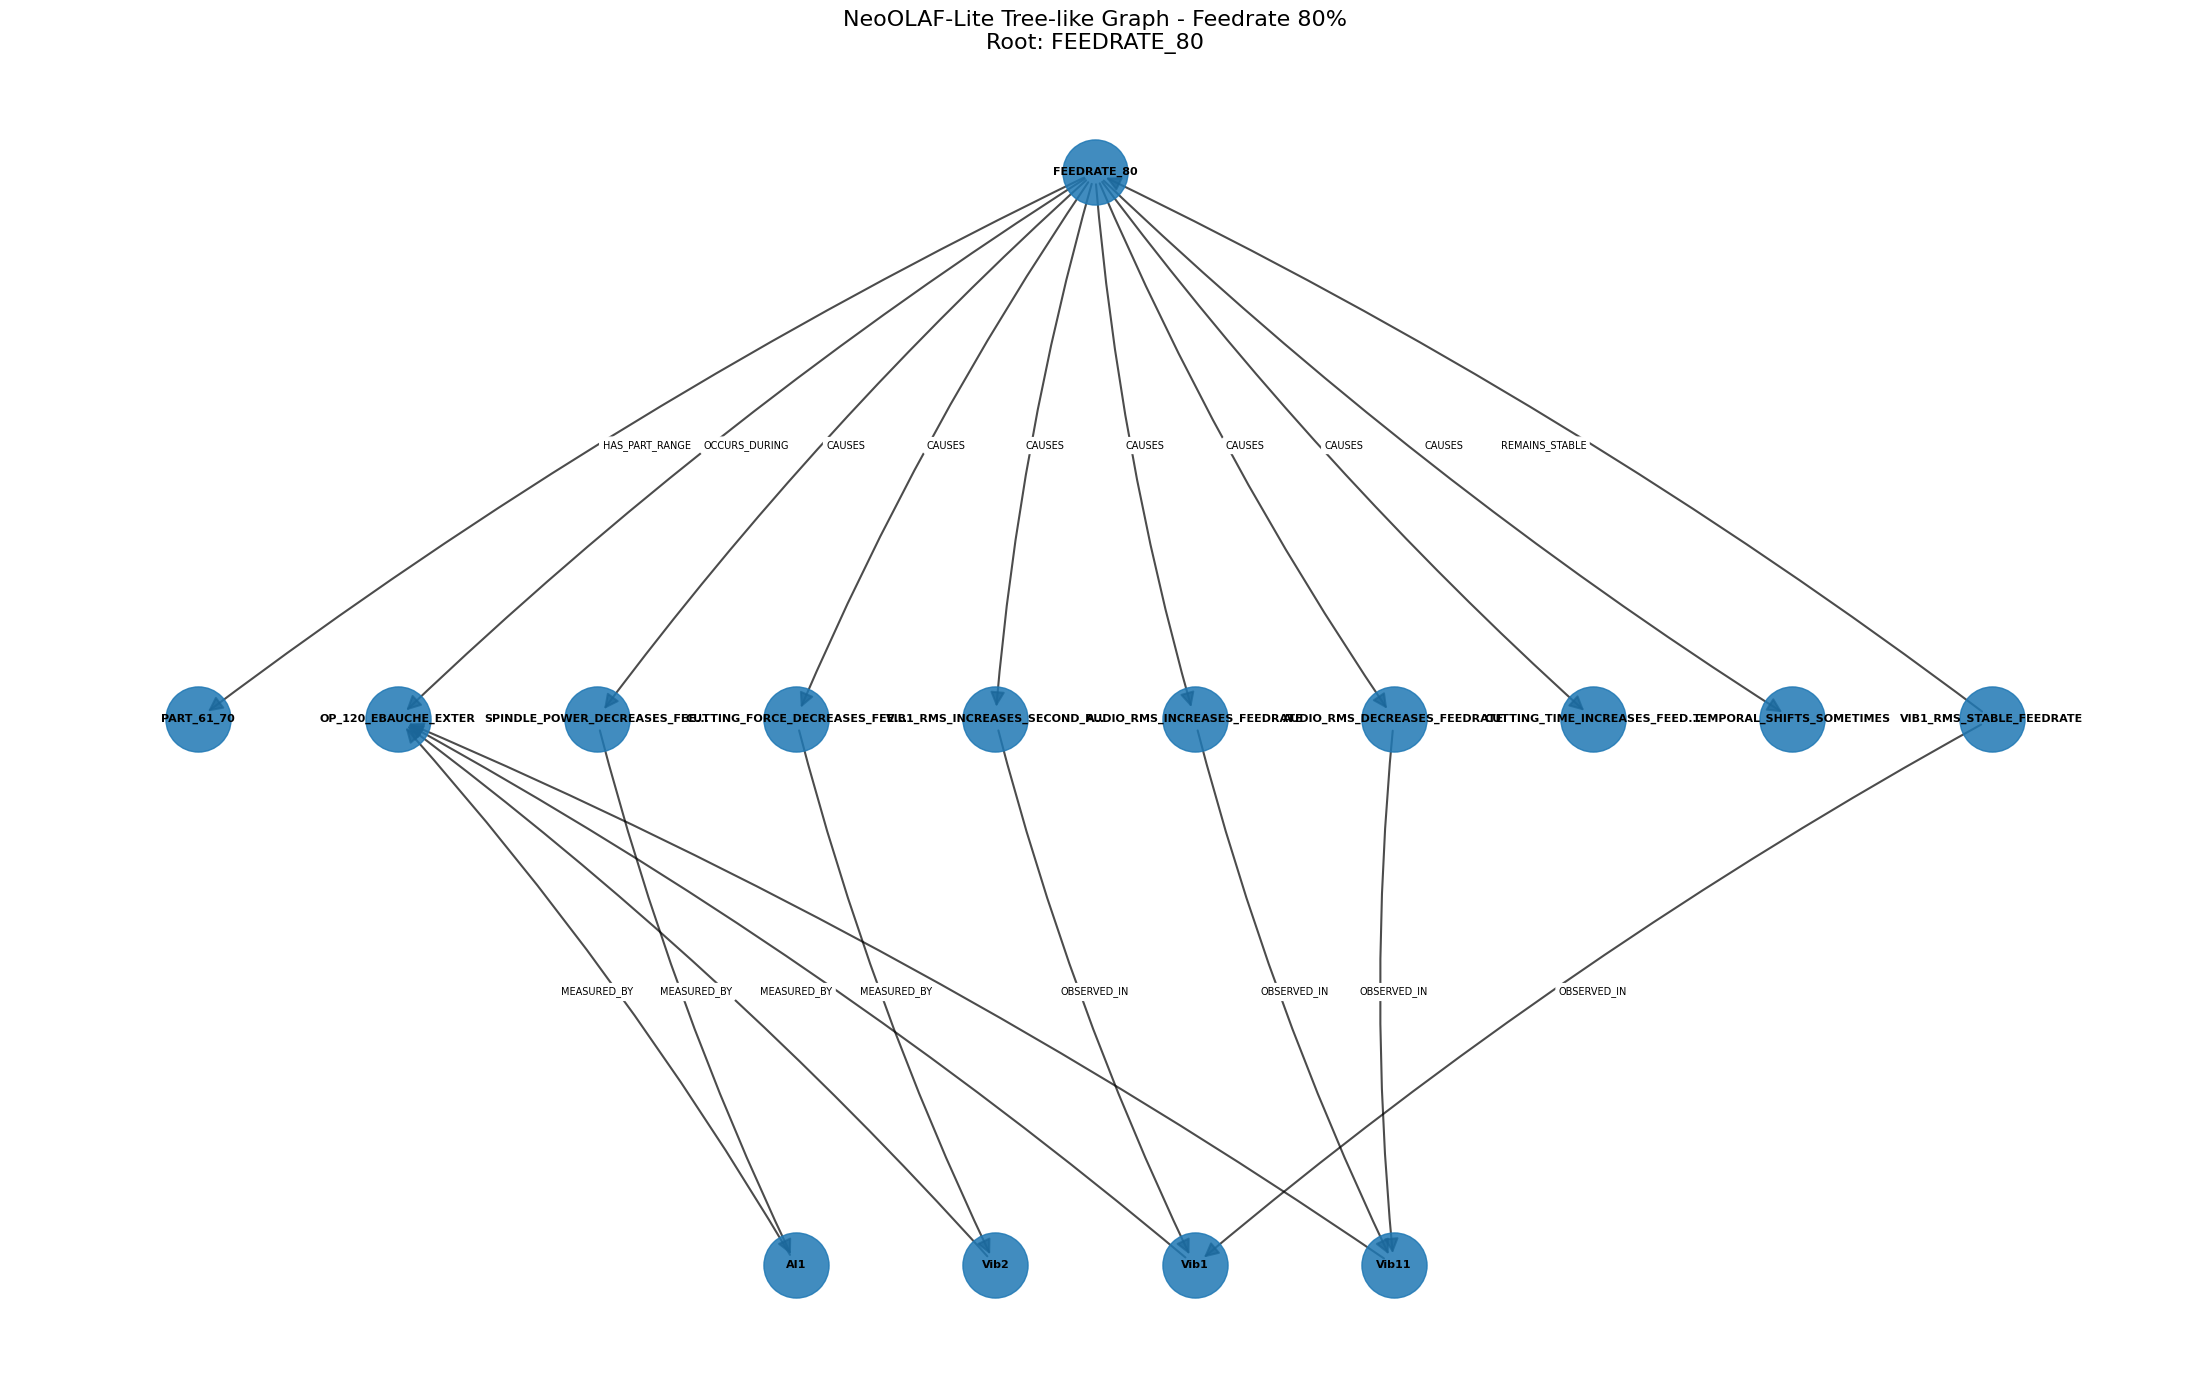

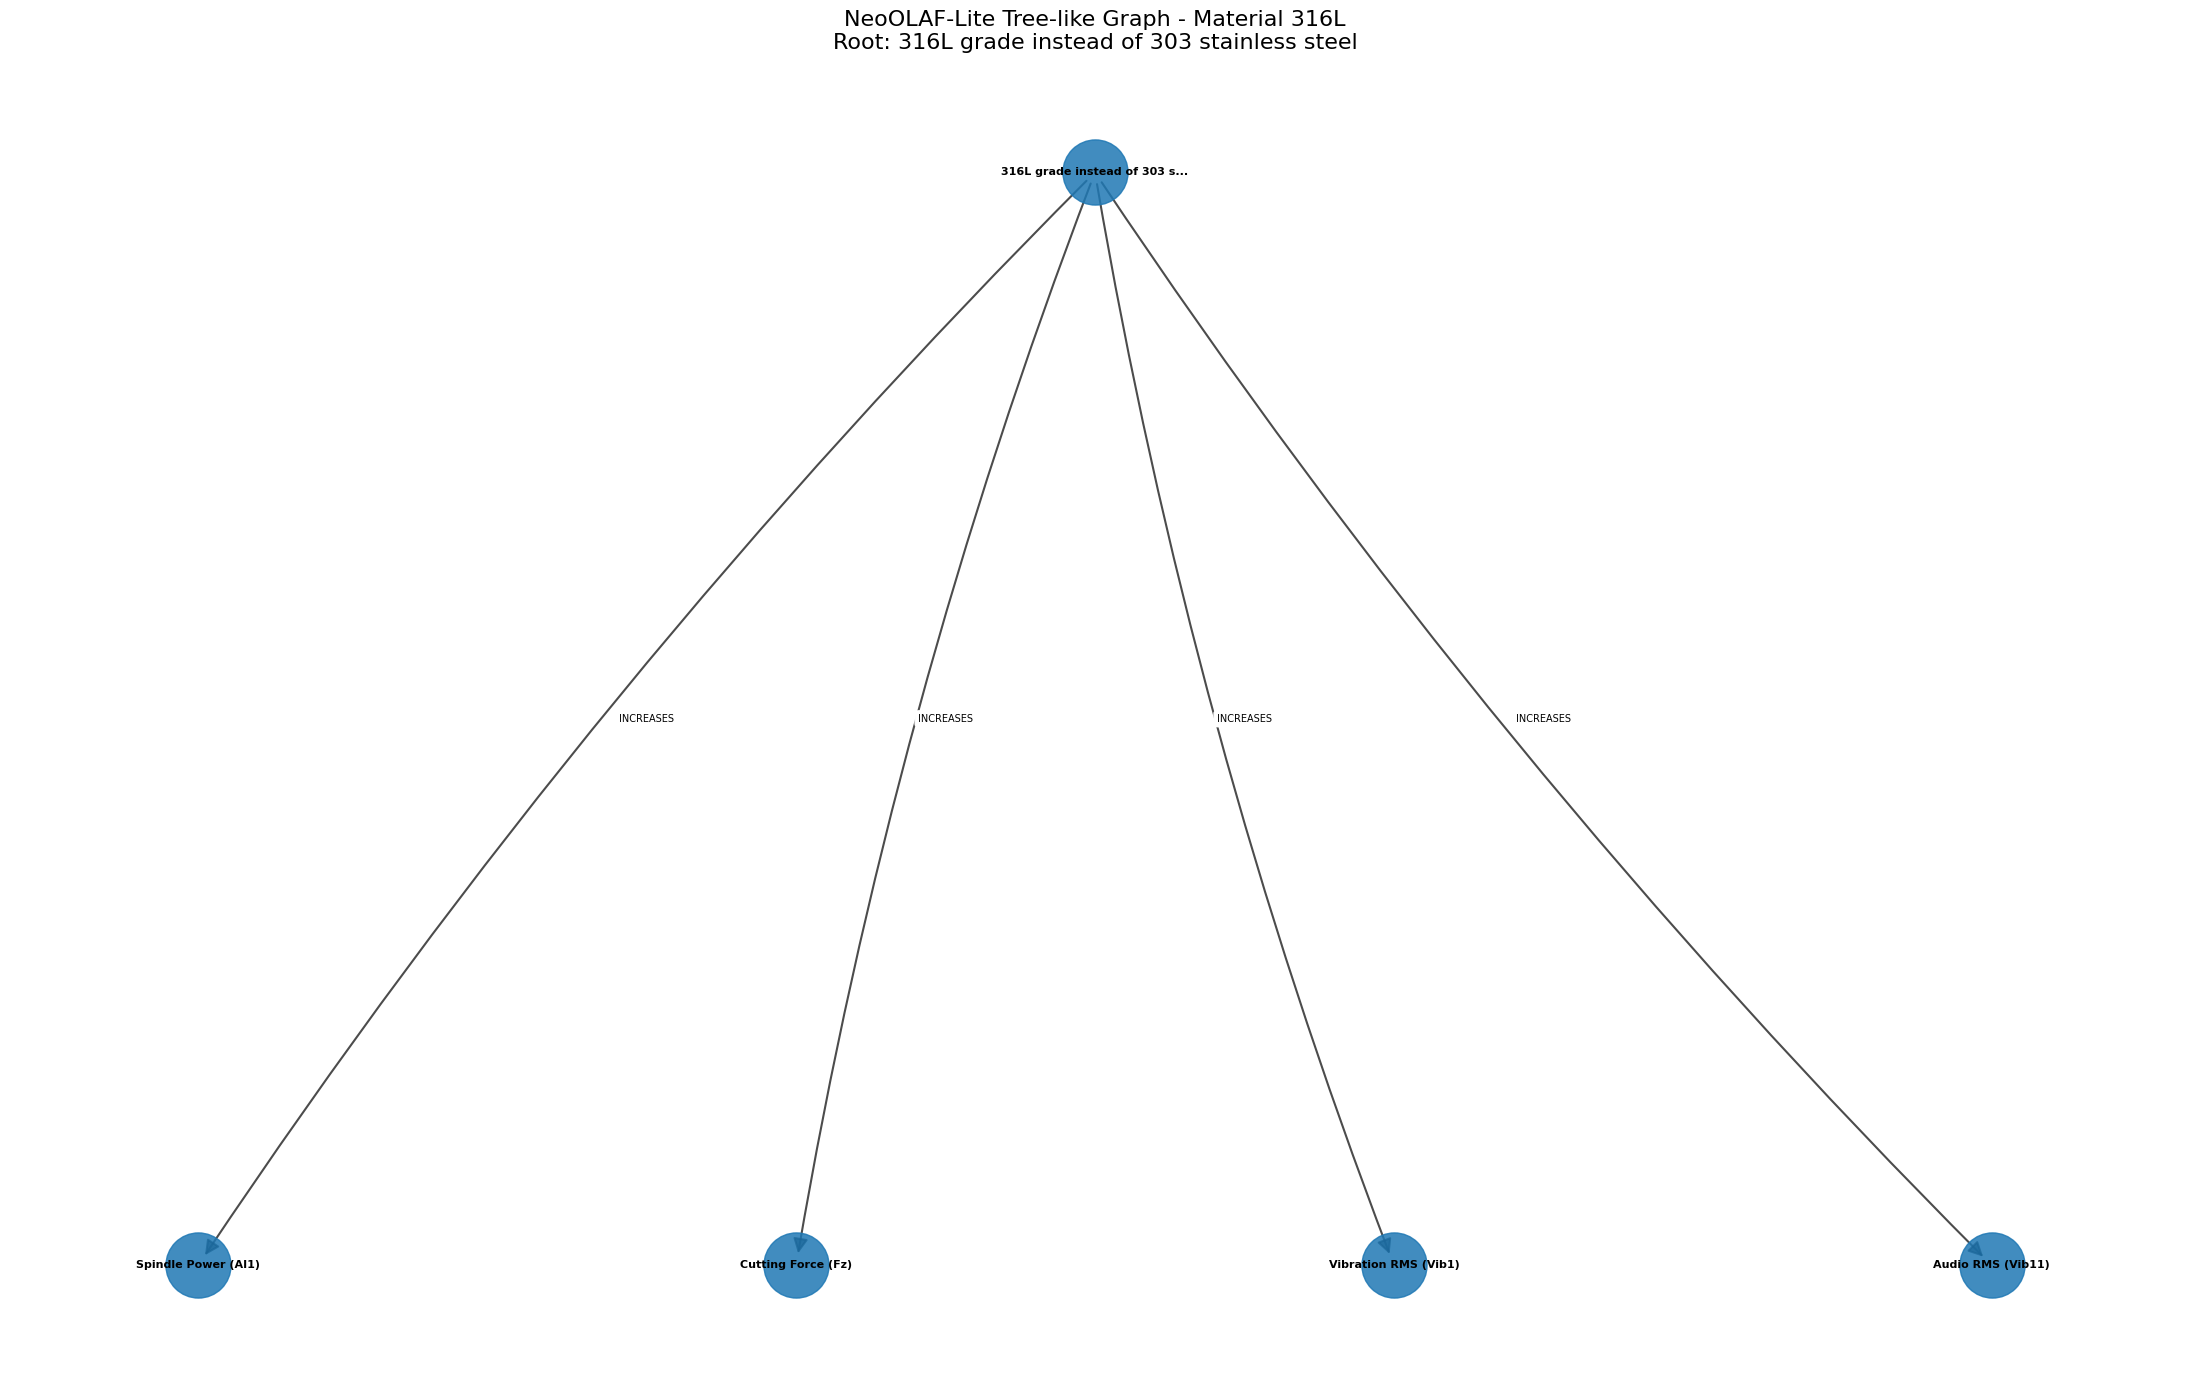

In [9]:
# ============================================================
# Tree-like plot + node/relation summary table for NeoOLAF-Lite
# ============================================================

from pathlib import Path
import json
import math
from collections import defaultdict

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path("../..").resolve()
RUNS_ROOT = PROJECT_ROOT / "runs/xquality_neoolaf_lite_gpt20"

CASES = ["feedrate_80", "material_316L"]


# ------------------------------------------------------------
# Load latest NeoOLAF-Lite output
# ------------------------------------------------------------

def find_latest_lite_json(case_id: str) -> Path:
    """Find the latest NeoOLAF-Lite JSON output for one case."""
    case_dir = RUNS_ROOT / case_id

    if not case_dir.exists():
        raise FileNotFoundError(f"Case directory not found: {case_dir}")

    candidates = sorted(
        case_dir.rglob(f"{case_id}_neoolaf_lite.json"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if not candidates:
        raise FileNotFoundError(f"No NeoOLAF-Lite JSON found for case: {case_id}")

    return candidates[0]


def load_lite_output(case_id: str) -> dict:
    """Load the latest NeoOLAF-Lite JSON output."""
    json_path = find_latest_lite_json(case_id)

    print(f"[LOAD] {case_id}: {json_path}")

    with json_path.open("r", encoding="utf-8") as f:
        return json.load(f)


# ------------------------------------------------------------
# Build graph
# ------------------------------------------------------------

def build_graph_from_lite_output(data: dict, min_confidence: float = 0.0) -> nx.DiGraph:
    """Build a directed graph from NeoOLAF-Lite triples."""
    graph = nx.DiGraph()

    triples = data.get("layer05_triples", {}).get("triples", [])

    for triple in triples:
        # Read confidence safely.
        confidence = triple.get("confidence", 1.0)

        try:
            confidence = float(confidence)
        except Exception:
            confidence = 1.0

        if confidence < min_confidence:
            continue

        subject = str(triple.get("subject", "")).strip()
        predicate = str(triple.get("predicate", "")).strip()
        obj = str(triple.get("object", "")).strip()

        if not subject or not predicate or not obj:
            continue

        # Add subject node.
        graph.add_node(
            subject,
            node_type=triple.get("subject_type", "unknown"),
        )

        # Add object node.
        graph.add_node(
            obj,
            node_type=triple.get("object_type", "unknown"),
        )

        # Add directed relation.
        graph.add_edge(
            subject,
            obj,
            label=predicate,
            evidence=triple.get("evidence", ""),
            page=triple.get("page", None),
            confidence=confidence,
            comparison_tags=triple.get("comparison_tags", {}),
        )

    return graph


# ------------------------------------------------------------
# Tree-like layout helper
# ------------------------------------------------------------

def choose_root(graph: nx.DiGraph, preferred_roots=None) -> str:
    """Choose a good root node for tree-like plotting."""
    preferred_roots = preferred_roots or []

    # Prefer nodes containing the main case condition.
    for preferred in preferred_roots:
        for node in graph.nodes:
            if preferred.lower() in node.lower():
                return node

    # Prefer nodes with high outgoing degree and low incoming degree.
    scores = {}

    for node in graph.nodes:
        scores[node] = (
            3 * graph.out_degree(node)
            - 2 * graph.in_degree(node)
            + graph.degree(node)
        )

    return max(scores, key=scores.get)


def hierarchy_positions(graph: nx.DiGraph, root: str) -> dict:
    """
    Create a simple top-down hierarchy layout.

    This works even if the graph is not a perfect tree:
    - It uses BFS levels from the selected root.
    - Unreachable nodes are placed in later levels.
    """
    undirected = graph.to_undirected()

    # Compute levels from root.
    levels = defaultdict(list)
    visited = set()

    if root in undirected:
        lengths = nx.single_source_shortest_path_length(undirected, root)

        for node, depth in lengths.items():
            levels[depth].append(node)
            visited.add(node)

    # Add disconnected nodes at the bottom.
    disconnected = [node for node in graph.nodes if node not in visited]

    if disconnected:
        max_level = max(levels.keys()) if levels else 0
        for i, node in enumerate(disconnected):
            levels[max_level + 1 + i // 6].append(node)

    # Assign x/y coordinates.
    pos = {}

    for depth in sorted(levels.keys()):
        nodes = levels[depth]
        width = len(nodes)

        for i, node in enumerate(nodes):
            # Center nodes horizontally.
            x = i - (width - 1) / 2
            y = -depth
            pos[node] = (x, y)

    return pos


def shorten_label(label: str, max_len: int = 28) -> str:
    """Shorten long graph labels."""
    label = str(label)

    if len(label) <= max_len:
        return label

    return label[: max_len - 3] + "..."


# ------------------------------------------------------------
# Tree-like plot
# ------------------------------------------------------------

def plot_tree_like_graph(
    graph: nx.DiGraph,
    title: str,
    preferred_roots=None,
    max_nodes: int = 45,
) -> None:
    """Plot graph in a top-down, almost-tree format."""
    if graph.number_of_nodes() == 0:
        print(f"[WARN] Empty graph for {title}")
        return

    # Keep most connected nodes if graph is too large.
    if graph.number_of_nodes() > max_nodes:
        degrees = dict(graph.degree())
        selected_nodes = sorted(degrees, key=degrees.get, reverse=True)[:max_nodes]
        graph = graph.subgraph(selected_nodes).copy()

    root = choose_root(graph, preferred_roots=preferred_roots)
    pos = hierarchy_positions(graph, root=root)

    plt.figure(figsize=(22, 14))

    # Draw nodes.
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=2200,
        alpha=0.85,
    )

    # Draw edges.
    nx.draw_networkx_edges(
        graph,
        pos,
        arrows=True,
        arrowsize=22,
        width=1.5,
        alpha=0.7,
        connectionstyle="arc3,rad=0.05",
    )

    # Draw shortened node labels.
    node_labels = {
        node: shorten_label(node, max_len=30)
        for node in graph.nodes
    }

    nx.draw_networkx_labels(
        graph,
        pos,
        labels=node_labels,
        font_size=8,
        font_weight="bold",
    )

    # Draw shortened relation labels.
    edge_labels = {
        (u, v): shorten_label(data.get("label", ""), max_len=20)
        for u, v, data in graph.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        graph,
        pos,
        edge_labels=edge_labels,
        font_size=7,
        rotate=False,
        label_pos=0.5,
    )

    plt.title(f"{title}\nRoot: {root}", fontsize=16)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Node/relation summary table
# ------------------------------------------------------------

def summarize_graph(case_id: str, graph: nx.DiGraph) -> dict:
    """Create one summary row for a graph."""
    node_types = defaultdict(int)
    relation_types = defaultdict(int)

    for _, attrs in graph.nodes(data=True):
        node_types[attrs.get("node_type", "unknown")] += 1

    for _, _, attrs in graph.edges(data=True):
        relation_types[attrs.get("label", "unknown")] += 1

    return {
        "case_id": case_id,
        "nodes": graph.number_of_nodes(),
        "relations": graph.number_of_edges(),
        "entity_nodes": node_types.get("entity", 0),
        "event_nodes": node_types.get("event", 0),
        "attribute_nodes": node_types.get("attribute", 0),
        "relation_nodes": node_types.get("relation", 0),
        "unknown_nodes": node_types.get("unknown", 0),
        "unique_relation_labels": len(relation_types),
        "top_relation_labels": ", ".join(
            f"{label} ({count})"
            for label, count in sorted(
                relation_types.items(),
                key=lambda x: x[1],
                reverse=True,
            )[:5]
        ),
    }


# ------------------------------------------------------------
# Run loading, summary, and plots
# ------------------------------------------------------------

graphs = {}
summary_rows = []

for case_id in CASES:
    data = load_lite_output(case_id)
    graph = build_graph_from_lite_output(data, min_confidence=0.0)

    graphs[case_id] = graph
    summary_rows.append(summarize_graph(case_id, graph))

summary_df = pd.DataFrame(summary_rows)

print("\nNode / Relation Summary")
display(summary_df)

# Plot feedrate case.
plot_tree_like_graph(
    graphs["feedrate_80"],
    title="NeoOLAF-Lite Tree-like Graph - Feedrate 80%",
    preferred_roots=["feedrate", "80%"],
    max_nodes=45,
)

# Plot material case.
plot_tree_like_graph(
    graphs["material_316L"],
    title="NeoOLAF-Lite Tree-like Graph - Material 316L",
    preferred_roots=["316L", "material"],
    max_nodes=45,
)